In [110]:
from helpers import *

import os
import re
import numpy as np
import matplotlib. pyplot as plt
from scipy.spatial.distance import directed_hausdorff

In [111]:
nubmer_points_list= [100, 200,300,400,500,600,700,800,900,1000,1100,1200, 1300,1400,1500]
n_runs= [10]

In [112]:
def calculate_distance(point1, point2):
    return sum((x - y) ** 2 for x, y in zip(point1, point2)) ** 0.5

def calculate_tolerance(points):
    num_points = len(points)
    tolerance = 1/num_points
    return tolerance
    
def count_repeated_points(points):
    #points = points[np.lexsort((points[:, 1], points[:, 0]))]
    n= len(points)
    ep=  calculate_tolerance(points)
    distinct_points = []

    for point in points:
        is_distinct = True
        for distinct_point in distinct_points:
            if calculate_distance(point, distinct_point) < ep:
                is_distinct = False
                break
        if is_distinct:
            distinct_points.append(point)
            
    return len(distinct_points), distinct_points

In [113]:
def KS_Test(data, algo):
    
    # Perform K-S test
    ks_statistic, p_value = stats.kstest(data, "uniform")#stats.kstest(ecdf.y, stats.uniform.cdf) #stats.kstest(ecdf.y, cdf_uniform)
    
    print("********START********")
    # Display the results
    print("******KS-Test for {}".format(algo),"*********")
    print(f"K-S Statistic: {ks_statistic}")
    print(f"P-Value: {p_value}")

    # Decision based on the p-value
    alpha = 0.05
    if p_value > alpha:
        print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
    else:
        print("Reject the null hypothesis: The sample does not follow the uniform distribution.")
    
    print("********END********")

# GSM

In [114]:
main_path = "../GSM/solns_runs/Ex10/"
subfolders = list_subfolders(main_path)

    
txt_files = list_subfolders(subfolders[0])
# list_txt_files(subfolders[0])

titles = [str(100*i) for i in range(1, 16)]

colors = [
    'blue', 'orange', 'r', 'yellow', 'purple',
    'brown', 'pink', 'gray', 'olive', 'cyan', 'red',
    'lightcoral', 'darkgoldenrod', 'mediumseagreen', 'green', 'mangeta'
]


## Number of starting points vs. PDP and HD

In [115]:
# Folders
# folders= {"n_runs_5":["../GSM/solns_runs/Ex1/N_{}/n_runs_5".format(str(pt)) for pt in nubmer_points_list],
#          "n_runs_10":["../GSM/solns_runs/Ex1/N_{}/n_runs_5".format(str(pt)) for pt in nubmer_points_list],
#          "n_runs_15":["../GSM/solns_runs/Ex1/N_{}/n_runs_5".format(str(pt)) for pt in nubmer_points_list],
#          "n_runs_20":["../GSM/solns_runs/Ex1/N_{}/n_runs_5".format(str(pt)) for pt in nubmer_points_list]}

folders= ["../GSM/solns_runs/Ex10/N_{}/".format(str(pt)) for pt in nubmer_points_list]
folders

['../GSM/solns_runs/Ex10/N_100/',
 '../GSM/solns_runs/Ex10/N_200/',
 '../GSM/solns_runs/Ex10/N_300/',
 '../GSM/solns_runs/Ex10/N_400/',
 '../GSM/solns_runs/Ex10/N_500/',
 '../GSM/solns_runs/Ex10/N_600/',
 '../GSM/solns_runs/Ex10/N_700/',
 '../GSM/solns_runs/Ex10/N_800/',
 '../GSM/solns_runs/Ex10/N_900/',
 '../GSM/solns_runs/Ex10/N_1000/',
 '../GSM/solns_runs/Ex10/N_1100/',
 '../GSM/solns_runs/Ex10/N_1200/',
 '../GSM/solns_runs/Ex10/N_1300/',
 '../GSM/solns_runs/Ex10/N_1400/',
 '../GSM/solns_runs/Ex10/N_1500/']

In [116]:
# folders['n_runs_5']

In [117]:
import os

def list_txt_files_in_directory(directory_path):
#     try:
#         # List all files and directories in the specified path
    files_and_directories = os.listdir(directory_path)
#     print(directory_path)
    # Filter and print only .txt files
    txt_files = [file for file in files_and_directories if file.endswith('.txt')]
    txt_files = [file for file in txt_files if '.txt' in file]
    txt_files.sort()
    txt_files= [directory_path+"/"+file for file in txt_files]
        
    return txt_files

In [118]:
def get_x1(x2):
    if 0 <= x2 <= 0.5:
        return 1-x2
    elif 0.5 <= x2 <= 3/4:
        return (3/2)-2*x2
            
n_times= 10
def get_values(folders):
    dist_= []
    avg_hd= []
    for pt in range(len(nubmer_points_list)):
        directory_path = folders[pt]

        files= list_txt_files_in_directory(directory_path)
        if len(files)>n_times:
            files= files[:n_times]
        res= []
        hd= []
        
        num_points= nubmer_points_list[pt]
        
        res_solns= []
        for file in files:
            
            if "._" in file:
                    file= file.replace("._","")
            
            solns= np.genfromtxt(file, delimiter=',')
            res_solns.extend(solns.tolist())
        
        
        res_solns= np.array(res_solns)
        num, distinct_points= count_repeated_points(res_solns)
        distinct_points= np.array(distinct_points)
        
        # Get PDP
        
        dist_.append((len(distinct_points)/(len(res_solns)))*100)
        
        # Get HD:
        
        x2= np.random.uniform(0.0, 3/4, len(distinct_points))
        x1= np.array([get_x1(i) for i in x2])
        points= np.concatenate((x1.reshape(-1,1),x2.reshape(-1,1)),1)


        

        print(len(distinct_points),len(res_solns))
        hausdorff_distance = directed_hausdorff(distinct_points, points)[0]
        avg_hd.append(hausdorff_distance)
        
    # Create subplots with different scales
    fig, ax1 = plt.subplots(figsize=(8, 4))

    # Create second axis with different scale
    ax1.set_xlabel('Number of starting points')
#     ax2 = ax1.twinx()
    ax1.set_ylim([0.0, np.max(dist_)])
    ax1.plot(nubmer_points_list, dist_, 'bo-')
    
#     ax1.set_yticks(dist_)
    
    ax1.set_ylabel('Perentage of distint points',color='blue')
#     ax1.set_ylabel('Perentage of distint points', color='b')


    # Create third axis with different scale
    ax2 = ax1.twinx()
    ax2.spines['right'].set_position(('outward', 60))  # Move the spine to the right
    ax2.plot(nubmer_points_list, avg_hd, 'go-')
    ax2.set_ylabel('Hausdorff Distance', color='g')
    ax2.set_ylim([0.0, np.max(avg_hd)])

    xticks = nubmer_points_list  # Precisely specify xticks from 0 to 10 with a step of 1
    ax1.set_xticks(xticks)
    ax1.set_xticklabels([f'{tick:.0f}' for tick in xticks])  # Format labels as strings with one decimal place


#     plt.savefig('./plots/Metrics/Ex1/ex1_gsm.jpeg')
    plt.savefig('../GSM/solns_runs/Ex10/plot_ex10.png')
# plt.xticks(list(range(len(possible_num_points))),possible_num_points)
    plt.grid(True)
    plt.show()

        
    return dist_,avg_hd

1 1000
1 2000
1 3000
1 4000
1 5000
1 6000
1 7000
1 8000
1 9000
1 10000
1 11000
1 12000
1 13000
1 14000
1 15000


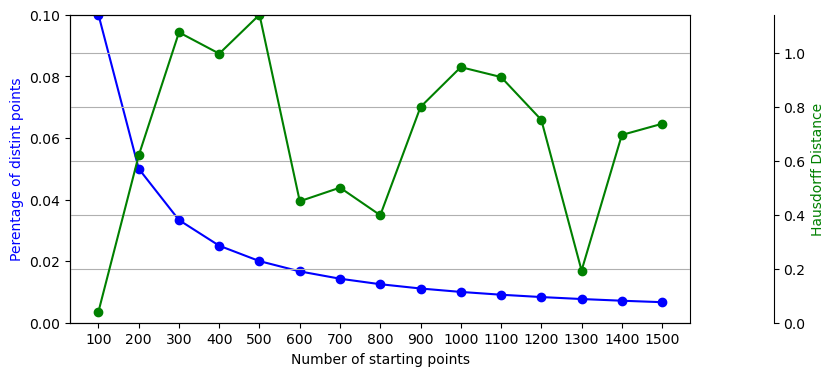

In [119]:
pdpgsm, hdgsm= get_values(folders)

In [120]:
for (p,h) in zip(pdpgsm, hdgsm):
    print(p, " * ", h)

0.1  *  0.04107411159365335
0.05  *  0.6205389583669095
0.03333333333333333  *  1.0774194952465919
0.025  *  0.9984167825227249
0.02  *  1.1428223337037193
0.016666666666666666  *  0.4507146092441011
0.014285714285714287  *  0.5012363554296502
0.0125  *  0.3988416409983447
0.011111111111111112  *  0.800632415616001
0.01  *  0.9483589513512662
0.00909090909090909  *  0.9115652143395858
0.008333333333333333  *  0.7526763292714934
0.007692307692307693  *  0.1934996524428532
0.0071428571428571435  *  0.696737999509247
0.006666666666666667  *  0.7381620814679456


In [121]:
max(pdpgsm), min(hdgsm)

(0.1, 0.04107411159365335)

In [122]:
def plot_solns(folders):
    all_solns= []
    for pt in range(len(nubmer_points_list)):
        directory_path = folders[pt]

        files= list_txt_files_in_directory(directory_path)
        res= []
        for file in files:
            solns= np.genfromtxt(file, delimiter=',')
            num, distinct_points = count_repeated_points(solns)
            distinct_points= np.array(distinct_points)
            res.extend(distinct_points.tolist())
#             break
            
        all_solns.append(res)
        
    
#     print(np.array(all_solns[0])[:,0])
    
    for i in range(len(all_solns)):
        print("Plot for {} points".format(nubmer_points_list[i]))
        plt.scatter(np.array(all_solns[i])[:,0], np.array(all_solns[i])[:,1], c= 'black')
        plt.xlim([0,1.0])
        plt.ylim([0,1.0])
        plt.grid(True)
        plt.show()

Plot for 100 points


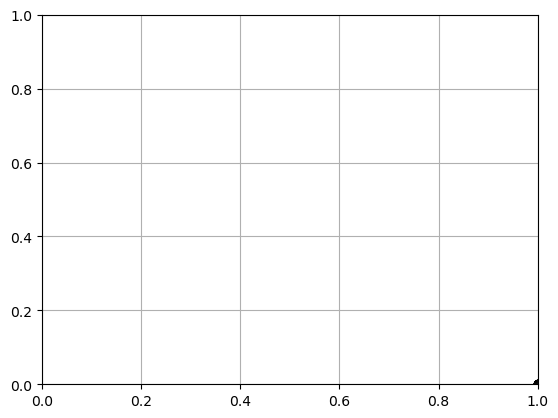

Plot for 200 points


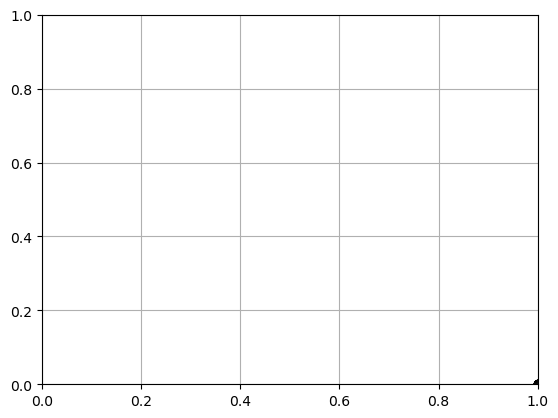

Plot for 300 points


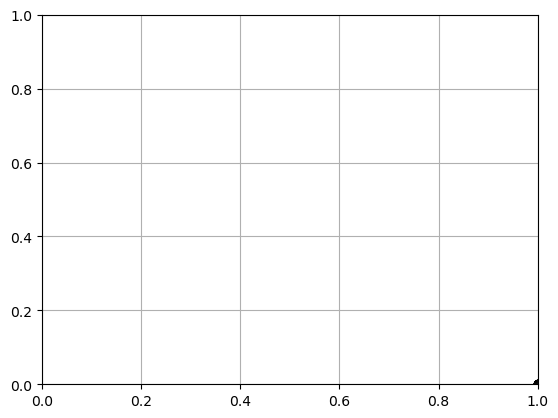

Plot for 400 points


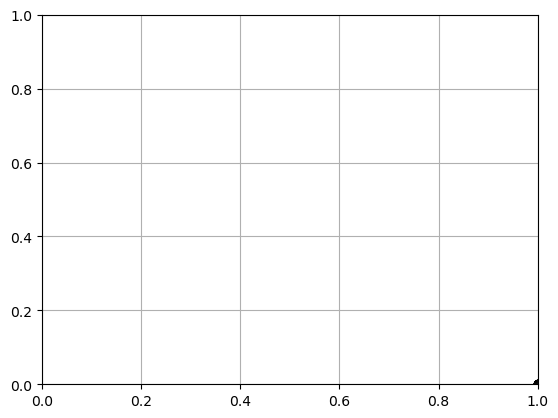

Plot for 500 points


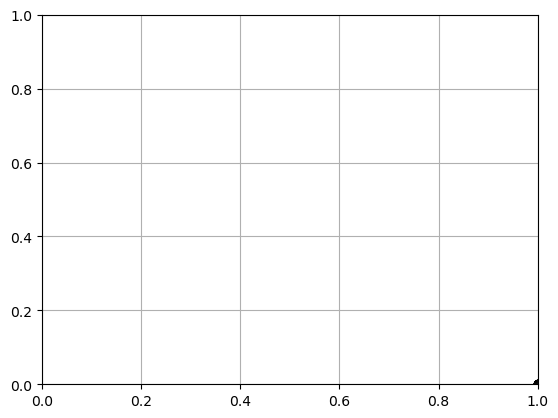

Plot for 600 points


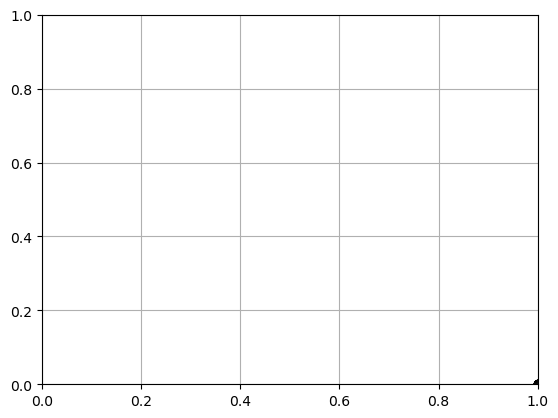

Plot for 700 points


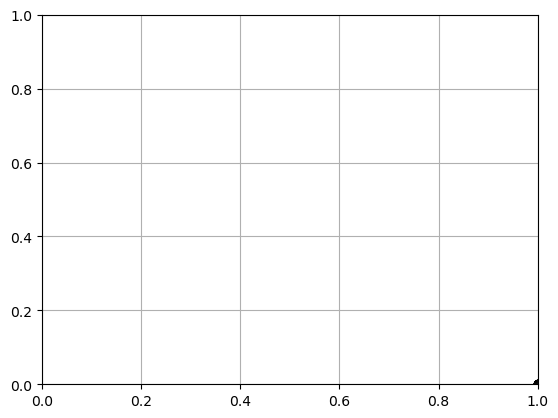

Plot for 800 points


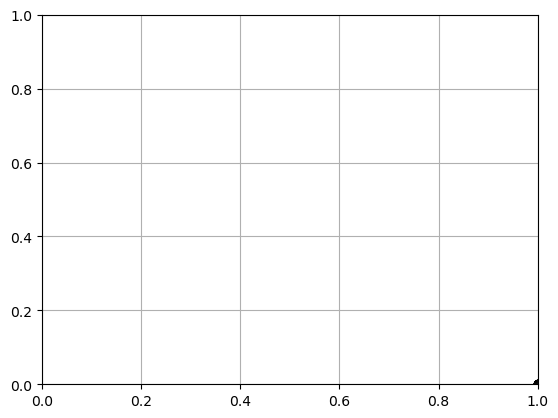

Plot for 900 points


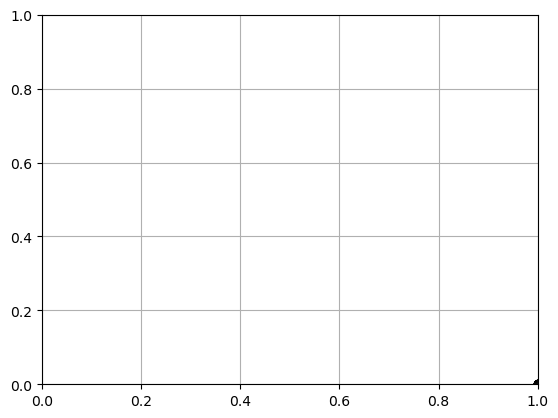

Plot for 1000 points


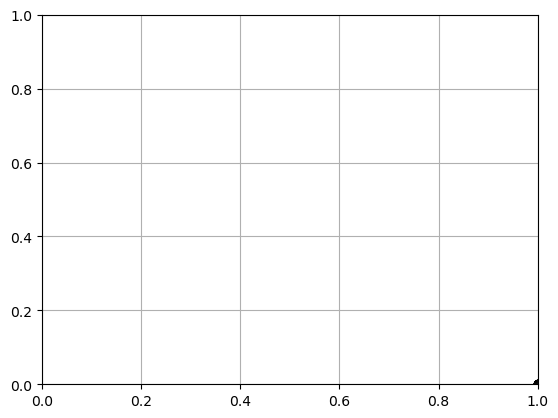

Plot for 1100 points


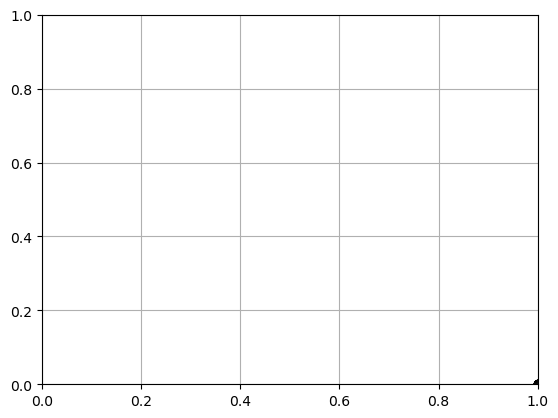

Plot for 1200 points


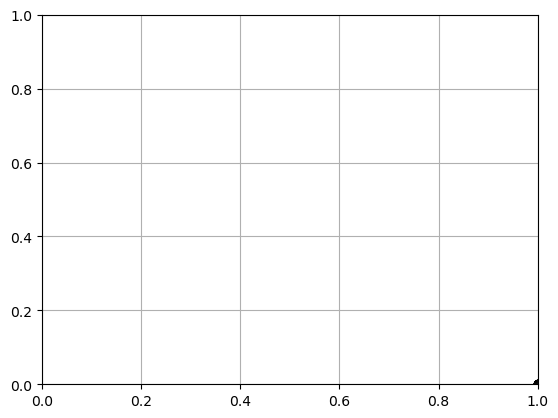

Plot for 1300 points


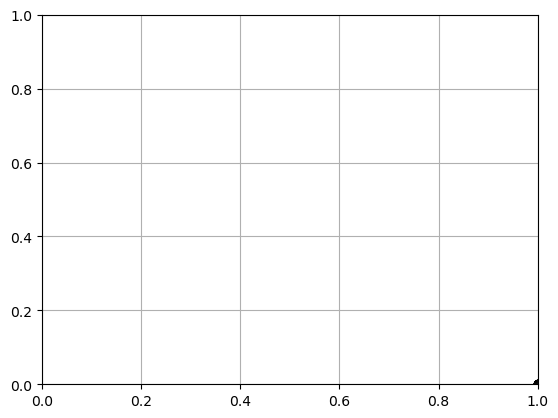

Plot for 1400 points


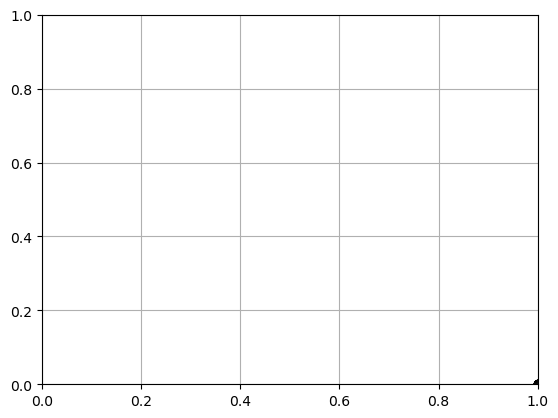

Plot for 1500 points


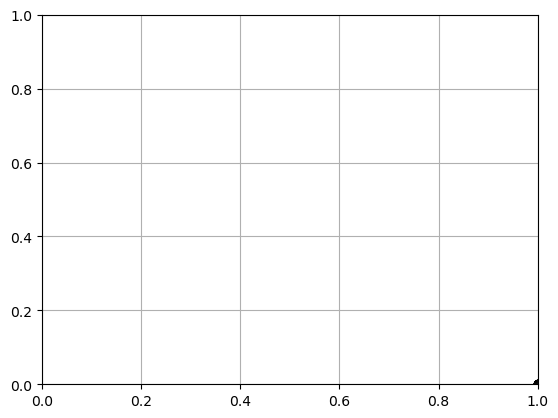

In [123]:
## Plot solution sets
plot_solns(folders)

In [124]:
np.argmax(pdpgsm)

0

## Histograms

In [125]:
# n_runs= 50 and 
n_points= nubmer_points_list[np.argmax(pdpgsm)]
print(n_points)
# Best
directory_path = "../GSM/solns_runs/Ex10/N_{}".format(n_points)
all_solnsgsm= []

files= list_txt_files_in_directory(directory_path)
if len(files)>n_times:
    files= files[:n_times]
for file in files:
    solns= np.genfromtxt(file, delimiter=',')

#     num, distinct_points = count_repeated_points(solns)
#     distinct_points= np.array(distinct_points)
    all_solnsgsm.extend(solns.tolist())

all_solnsgsm= np.array(all_solnsgsm)
num, all_solnsgsm = count_repeated_points(all_solnsgsm)
all_solnsgsm= np.array(all_solnsgsm)
print(len(all_solnsgsm))

100
1


In [126]:
all_solnsgsm

array([[1., 0.]])

In [127]:
len(all_solnsgsm)
# print(all_solnsgsm)

1

In [128]:
def partition_interval(a, b, n):
#     n= n-1
    interval_length = b - a
    partition_width = interval_length / n
    partition_points = [a + i * partition_width for i in range(n + 1)]
    return partition_points

def count_values_in_bins(values, bins):
    # Initialize a dictionary to store the counts for each bin
    bin_counts = {bin_index: 0 for bin_index in range(len(bins) - 1)}

    # Iterate over each value
    for value in values:
        # Find the bin that the value falls into
        bin_index = 0
        while bin_index < len(bins) - 1 and not (bins[bin_index] <= value <= bins[bin_index + 1]):
            bin_index += 1

        # Increment the count for the corresponding bin.
        if bin_index < len(bins) - 1:
            bin_counts[bin_index] += 1

    return bin_counts

## x:
bins_list= [5,10,15,20]
solns= all_solnsgsm.copy()


## y:
y=  solns[:,1]
y_min = np.min(y)
y_max = np.max(y)

x= np.array([get_x1(i) for i in y])
x_min = np.min(x)
x_max = np.max(x)

# y

xgsm= x.copy()
ygsm= y.copy()

In [129]:
for (i,j) in zip(xgsm,ygsm):
    print(i,j)

1.0 0.0


In [130]:
x

array([1.])

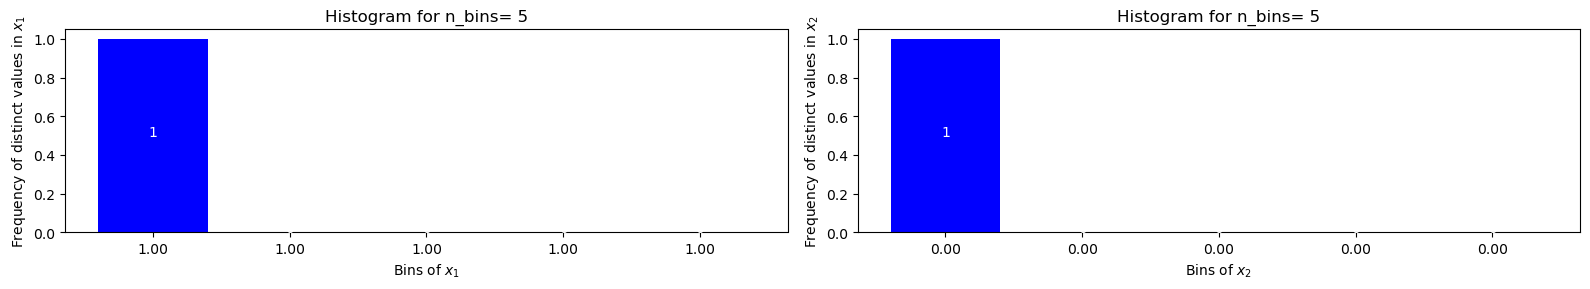

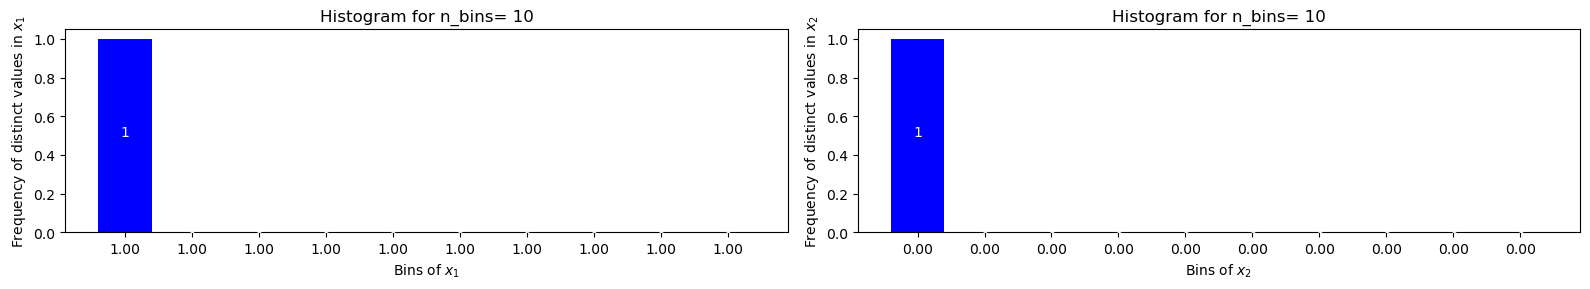

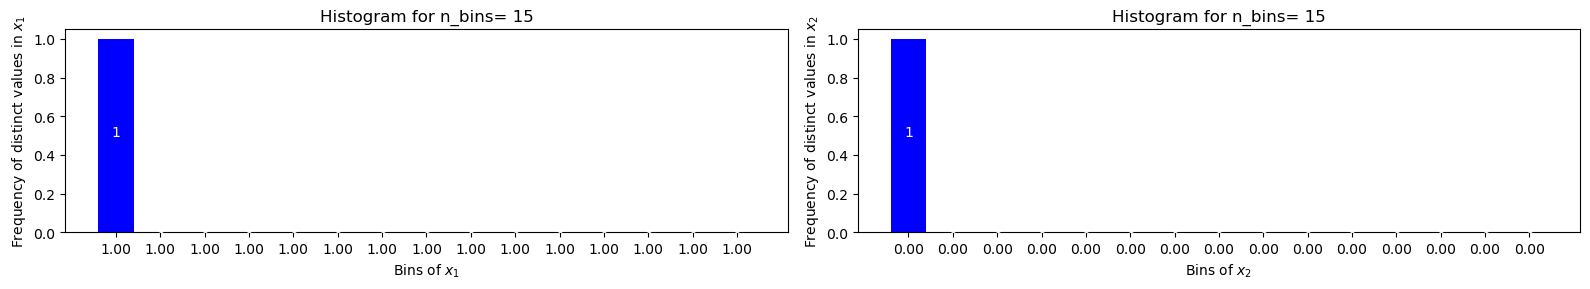

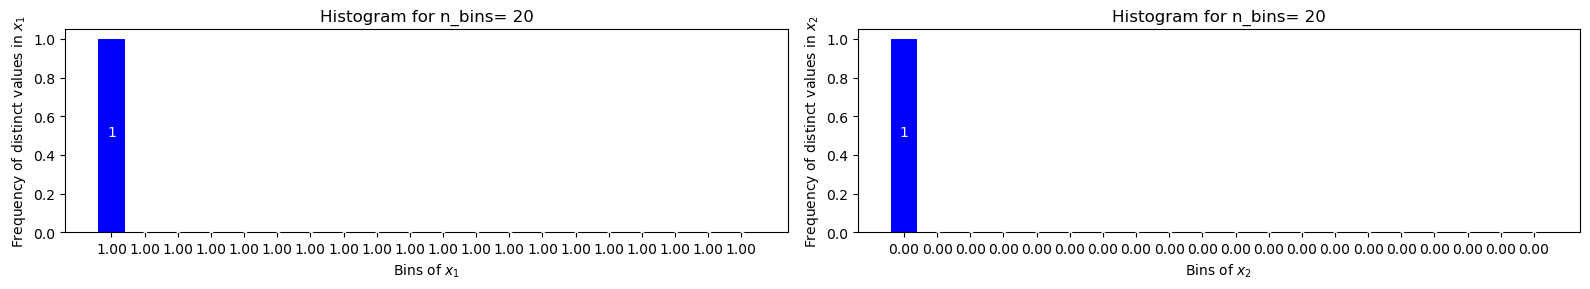

In [131]:
x_hist_gsm= []
y_hist_gsm= []
y_part_gsm= []
x_part_gsm= []
for n_bins in bins_list:
    partition_points = partition_interval(x_min, x_max, n_bins)
    x_part_gsm.append(partition_points)
#     print("Partition points:", partition_points)
    bin_counts = count_values_in_bins(x, partition_points)
    x_hist_gsm.append(bin_counts)
#     bin_counts= get_per(bin_counts)
#     print("Counts in each bin:", bin_counts)

    y_partition_points = partition_interval(y_min, y_max, n_bins)
    y_part_gsm.append(y_partition_points)
    y_bin_counts = count_values_in_bins(y, y_partition_points)
    y_hist_gsm.append(y_bin_counts)
    
#     y_bin_counts= get_per(y_bin_counts)
#     print("Counts in each bin:", y_bin_counts)


    plt.figure(figsize=(16, 3))

    plt.subplot(1, 2, 1)
    bars = plt.bar(range(len(bin_counts)), bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(bin_counts)), ["{:.2f}".format(b) for b in partition_points[:-1]])
    plt.xlabel('Bins of $x_1$')
    plt.ylabel('Frequency of distinct values in $x_1$')
    plt.title('Histogram for n_bins= {}'.format(len(bin_counts)))
#     plt.grid(True)

    plt.subplot(1, 2, 2)
    bars = plt.bar(range(len(y_bin_counts)), y_bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(y_bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(y_bin_counts)), ["{:.2f}".format(b) for b in y_partition_points[:-1]])
    plt.xlabel('Bins of $x_2$')
    plt.ylabel('Frequency of distinct values in $x_2$')
    plt.title('Histogram for n_bins= {}'.format(len(y_bin_counts)))
#     plt.grid(True)
    plt.tight_layout()
    plt.savefig('../GSM/solns_runs/Ex10/'+'ex10_gsm_hist'+str(n_bins)+'.png')
    plt.show()

## Uniform CDF vs. empirical CDF

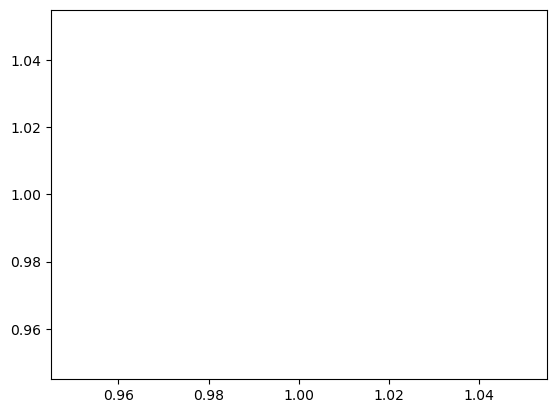

In [132]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from matplotlib import pyplot
from numpy.random import normal
from numpy import hstack
from statsmodels.distributions.empirical_distribution import ECDF
# fit a cdf
ecdf = ECDF(xgsm)
plt.plot(ecdf.x, ecdf.y)
plt.show()


def get_cdf_of_uniform(x, a, b):
    if x<a:
        return 0
    elif a<=x<b:
        return (x-a)/(b-a)
    elif x>b:
        return 1

## KS-Test

In [133]:
import numpy as np
from scipy import stats

# Example data (replace with your actual data)
np.random.seed(0)
data = np.random.uniform(0,1, size=100)

# Perform KS test against a normal distribution (null hypothesis)
ks_statistic, p_value = stats.kstest(data, 'norm')

# Print the results
print(f"KS Statistic: {ks_statistic}")
print(f"P-value: {p_value}")

# Interpret the results
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis that the data is normally distributed.")
else:
    print("Cannot reject the null hypothesis that the data is normally distributed.")


KS Statistic: 0.5018732170965315
P-value: 7.902176095057781e-24
Reject the null hypothesis that the data is normally distributed.


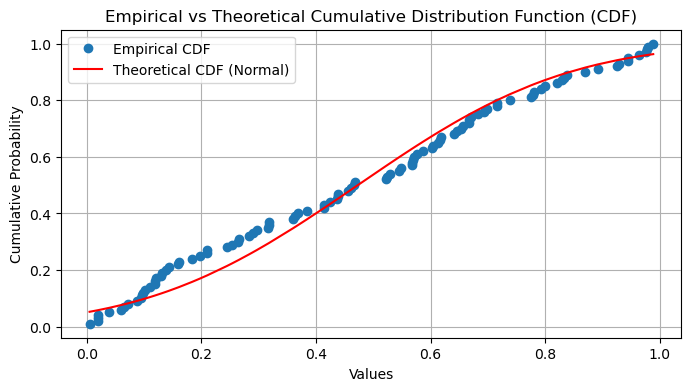

In [134]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Example data (replace with your actual data)
np.random.seed(0)
# data = np.random.normal(loc=0, scale=1, size=100)

# Sort the data
sorted_data = np.sort(data)

# Calculate the empirical CDF
n = sorted_data.size
y_empirical = np.arange(1, n+1) / n

# Calculate the theoretical CDF (normal distribution)
mean, std = np.mean(data), np.std(data)
y_theoretical = stats.norm.cdf(sorted_data, loc=mean, scale=std)

# Plotting the empirical and theoretical CDFs
plt.figure(figsize=(8, 4))
plt.plot(sorted_data, y_empirical, label='Empirical CDF', marker='o', linestyle='none')
plt.plot(sorted_data, y_theoretical, label='Theoretical CDF (Normal)', color='red')
plt.xlabel('Values')
plt.ylabel('Cumulative Probability')
plt.title('Empirical vs Theoretical Cumulative Distribution Function (CDF)')
plt.legend()
plt.grid(True)
plt.show()


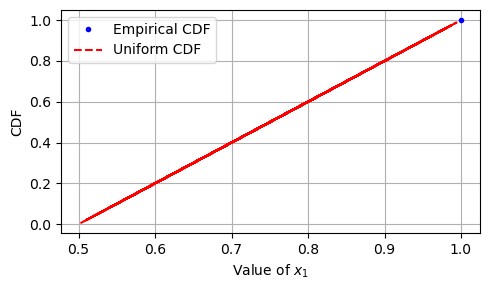

K-S Statistic: 1.0
P-Value: 0.0
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [135]:
# KS Test on x: 
a,b=0.5, 1.0
uniform_samples = np.random.uniform(low=a, high=b, size=100)
# uniform_samples= np.hstack((uniform_samples,0.0))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

# Number of samples
n_samples = len(x)

# Generate uniform values in [0,1]
#uniform_samples = np.random.uniform(low=0.0, high=1.0, size=n_samples)

# Plotting the histogram of uniform samples
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(xgsm)
ecdf_gsm_x = ECDF(xgsm) #np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_gsm_x.x, ecdf_gsm_x.y, marker='.', linestyle='none', label='Empirical CDF',c= 'blue')
# plt.plot([5.0],[1], 'r--')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples,cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiric')
plt.xlabel('Value of $x_1$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../GSM/solns_runs/Ex10/ks_ex10_x1.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(xgsm, "uniform")#stats.kstest(ecdf.y, stats.uniform.cdf) #stats.kstest(ecdf.y, cdf_uniform)

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")

In [136]:
1/3

0.3333333333333333

In [137]:
ecdf_gsm_x.x

array([-inf,   1.])

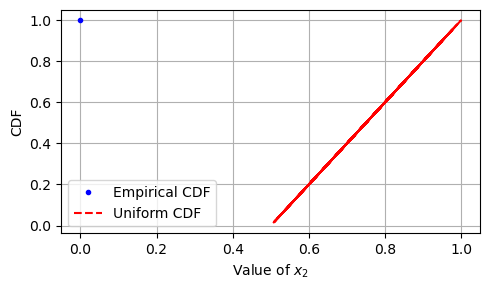

K-S Statistic: 1.0
P-Value: 0.0
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [138]:
# KS Test on y: 
# Number of samples
a,b= 0.5, 1.0
uniform_samples = np.random.uniform(low=a, high=b, size=100)
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

n_samples = len(x)
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(ygsm)
ecdf_gsm_y = ECDF(ygsm) # np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_gsm_y.x, ecdf_gsm_y.y, marker='.', linestyle='none', label='Empirical CDF', c= 'blue')
# plt.plot([1-1, 1-0.5], [1-1, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples, cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples')
plt.xlabel('Value of $x_2$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../GSM/solns_runs/Ex10/ks_ex10_x2.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(ygsm, "uniform")

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")


# PVI

In [139]:
nubmer_points_list= [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500]
# nubmer_points_list= nubmer_points_list[:13]
nubmer_points_list

[100,
 200,
 300,
 400,
 500,
 600,
 700,
 800,
 900,
 1000,
 1100,
 1200,
 1300,
 1400,
 1500]

In [140]:
from math import *
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar


import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar


# Define objective functions for each player
def player1_objective(x):
    return -x[0]

def player2_objective(x):
    return 0.0


# Define constraints for each player
def constraint_function1(x):
    return 1-(x[0]+x[1])

def constraint_function2(x):
    return 3-(2*x[0]+4*x[1])

# def grad_cons1(x):
#   return np.array([-3.25, -1.25, -4.125])

def constraint_function(x):
  return np.array([constraint_function1(x),constraint_function2(x)])

In [141]:
# New

## Load data

import json

# with open('../Scripts/PVI/Ex3PVI.json') as f:
#     data= json.load(f)

with open('../Scripts/PVI/Ex9PVIT.json') as f:
    dataT= json.load(f)

T_list= [1, 2, 3, 4, 5]
data_dict= dict.fromkeys(range(1, len(T_list)+1), 0)

data_dict



for T in T_list:
    data_all= []

    for i in range(len(nubmer_points_list)):
        res_= []

        if len(dataT[str(T)][i])== 0:
            # print(dataT[str(1)][i])
            data_all.append([dataT[str(T)][i]])
            # res_.append([dataT[str(1)][i]])
        else:
            
            for t in range(len(dataT[str(T)][i])):
                #print(data[str(i)][t])
                #if np.abs(constraint_function(dataT[str(T)][i][t]))<= 1e-6:
                res_.append(dataT[str(T)][i][t])
            data_all.append(res_)
    data_dict[T]= data_all


res_all= []

for i in range(len(nubmer_points_list)):
    res= []
    for T in T_list:
        res.extend(data_dict[T][i])

    res_all.append(res)

In [142]:
data_all= res_all

In [143]:
def calculate_distance(point1, point2):
    return sum((x - y) ** 2 for x, y in zip(point1, point2)) ** 0.5

def calculate_tolerance(points):
    num_points = len(points)
    tolerance = 1/num_points
    return tolerance
    
def count_repeated_points(points):
    #points = points[np.lexsort((points[:, 1], points[:, 0]))]
    n= len(points)
    ep=  calculate_tolerance(points)
    distinct_points = []

    for point in points:
        is_distinct = True
        for distinct_point in distinct_points:
            if calculate_distance(point, distinct_point) < ep:
                is_distinct = False
                break
        if is_distinct:
            distinct_points.append(point)
            
    return len(distinct_points), distinct_points

In [144]:
data= []
dist_= []
avg_hd= []

for (idx, pt) in enumerate(nubmer_points_list):
    dt= []
    

    num_points= nubmer_points_list[idx]

    num, distinct_points = count_repeated_points(np.array(data_all[idx]))
    distinct_points= np.array(distinct_points)  

    x2= np.random.uniform(0.0, 3/4, len(distinct_points))
    x1= np.array([get_x1(i) for i in x2])
    points= np.concatenate((x1.reshape(-1,1),x2.reshape(-1,1)),1)
    
    
    hausdorff_distance = directed_hausdorff(np.array(data_all[idx]), points)[0]
    dist_.append((len(distinct_points)/(len(data_all[idx])))*100)
    avg_hd.append(hausdorff_distance)

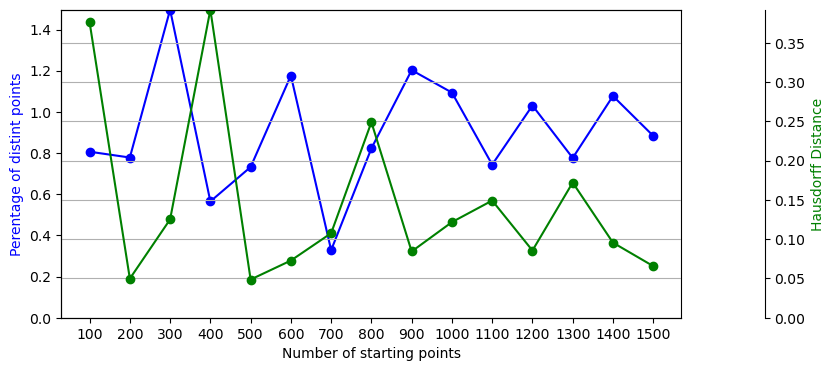

In [145]:
fig, ax1 = plt.subplots(figsize=(8, 4))

# Create second axis with different scale
ax1.set_xlabel('Number of starting points')
#     ax2 = ax1.twinx()
ax1.set_ylim([0.0, np.max(dist_)])
ax1.plot(nubmer_points_list, dist_, 'bo-')
    
#     ax1.set_yticks(dist_)
    
ax1.set_ylabel('Perentage of distint points',color='blue')
#     ax1.set_ylabel('Perentage of distint points', color='b')


# Create third axis with different scale
ax2 = ax1.twinx()
ax2.spines['right'].set_position(('outward', 60))  # Move the spine to the right
ax2.plot(nubmer_points_list, avg_hd, 'go-')
ax2.set_ylabel('Hausdorff Distance', color='g')
ax2.set_ylim([0.0, np.max(avg_hd)])

xticks = nubmer_points_list  # Precisely specify xticks from 0 to 10 with a step of 1
ax1.set_xticks(xticks)
ax1.set_xticklabels([f'{tick:.0f}' for tick in xticks])  # Format labels as strings with one decimal place


plt.savefig('../PVI/solns_runs/Ex10/plot_ex10.png')
plt.grid(True)
plt.show()

In [146]:
pdppvi, hdgpvi= dist_.copy(),avg_hd.copy()

In [147]:
pdppvi

[0.8064516129032258,
 0.7782101167315175,
 1.4962593516209477,
 0.5649717514124294,
 0.7320644216691069,
 1.1764705882352942,
 0.3282275711159737,
 0.8226691042047531,
 1.202749140893471,
 1.09375,
 0.7437457741717377,
 1.0309278350515463,
 0.7761194029850746,
 1.0770059235325793,
 0.8835758835758836]

In [148]:
hdgpvi

[0.3763973073344486,
 0.04976960732792089,
 0.12525350894058232,
 0.3923271542647536,
 0.04863332063269284,
 0.07283856654570366,
 0.10764852678560213,
 0.249026381060444,
 0.08440570634211525,
 0.1217742911739871,
 0.14923580144498008,
 0.0855993378531968,
 0.1721577848188981,
 0.095622330845678,
 0.06574014391603886]

In [149]:
for (p,h) in zip(pdppvi,hdgpvi):
    print(p, " *** ", h)

0.8064516129032258  ***  0.3763973073344486
0.7782101167315175  ***  0.04976960732792089
1.4962593516209477  ***  0.12525350894058232
0.5649717514124294  ***  0.3923271542647536
0.7320644216691069  ***  0.04863332063269284
1.1764705882352942  ***  0.07283856654570366
0.3282275711159737  ***  0.10764852678560213
0.8226691042047531  ***  0.249026381060444
1.202749140893471  ***  0.08440570634211525
1.09375  ***  0.1217742911739871
0.7437457741717377  ***  0.14923580144498008
1.0309278350515463  ***  0.0855993378531968
0.7761194029850746  ***  0.1721577848188981
1.0770059235325793  ***  0.095622330845678
0.8835758835758836  ***  0.06574014391603886


In [150]:
max(dist_), min(avg_hd)

(1.4962593516209477, 0.04863332063269284)

In [151]:
pdppvi_all, hdgpvi_all= dist_.copy(),avg_hd.copy()

In [152]:
pdppvi_all

[0.8064516129032258,
 0.7782101167315175,
 1.4962593516209477,
 0.5649717514124294,
 0.7320644216691069,
 1.1764705882352942,
 0.3282275711159737,
 0.8226691042047531,
 1.202749140893471,
 1.09375,
 0.7437457741717377,
 1.0309278350515463,
 0.7761194029850746,
 1.0770059235325793,
 0.8835758835758836]

In [153]:
hdgpvi_all

[0.3763973073344486,
 0.04976960732792089,
 0.12525350894058232,
 0.3923271542647536,
 0.04863332063269284,
 0.07283856654570366,
 0.10764852678560213,
 0.249026381060444,
 0.08440570634211525,
 0.1217742911739871,
 0.14923580144498008,
 0.0855993378531968,
 0.1721577848188981,
 0.095622330845678,
 0.06574014391603886]

In [154]:
avg_hd

[0.3763973073344486,
 0.04976960732792089,
 0.12525350894058232,
 0.3923271542647536,
 0.04863332063269284,
 0.07283856654570366,
 0.10764852678560213,
 0.249026381060444,
 0.08440570634211525,
 0.1217742911739871,
 0.14923580144498008,
 0.0855993378531968,
 0.1721577848188981,
 0.095622330845678,
 0.06574014391603886]

In [155]:
# Best npoint
sol= np.array(data_all[np.argmax(pdppvi)])
num, distinct_points = count_repeated_points(sol)
solnspvi= np.array(distinct_points)
print(solnspvi)

[[0.5        0.5       ]
 [0.40069693 0.5496486 ]
 [0.36887949 0.56555725]
 [0.50256067 0.4974347 ]
 [0.39287689 0.55355864]
 [0.56071108 0.43928439]]


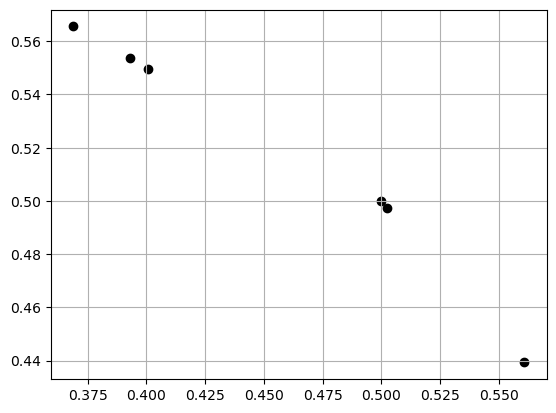

In [156]:
plt.scatter(solnspvi[:,0], solnspvi[:,1], c= 'black')
#plt.xlim([0,1.0])
#plt.ylim([0,1.0])
plt.grid(True)
plt.show()

## Histogram

In [157]:
## x:
bins_list= [5,10,15,20]
solns= solnspvi.copy()


## y:
y=  solns[:,1]
y_min = np.min(y)
y_max = np.max(y)

x= np.array([get_x1(i) for i in y])
x_min = np.min(x)
x_max = np.max(x)

# y

xpvi= x.copy()
ypvi= y.copy()

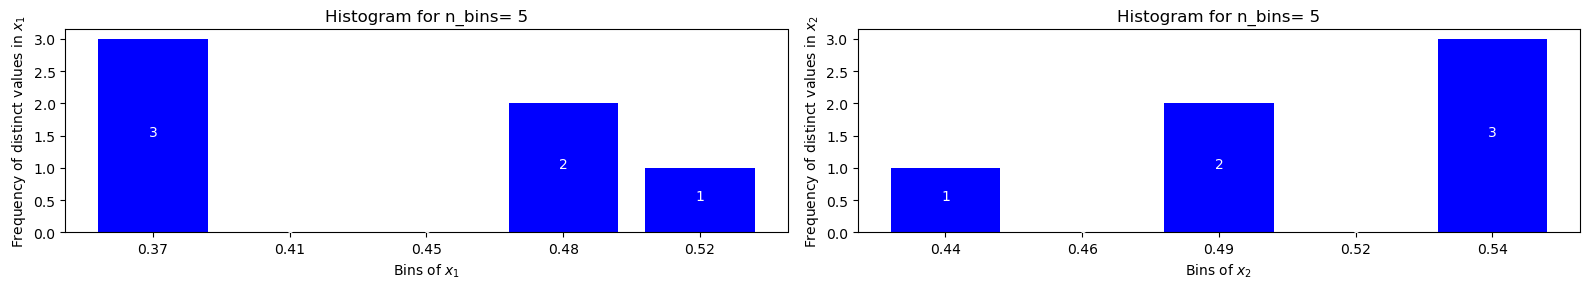

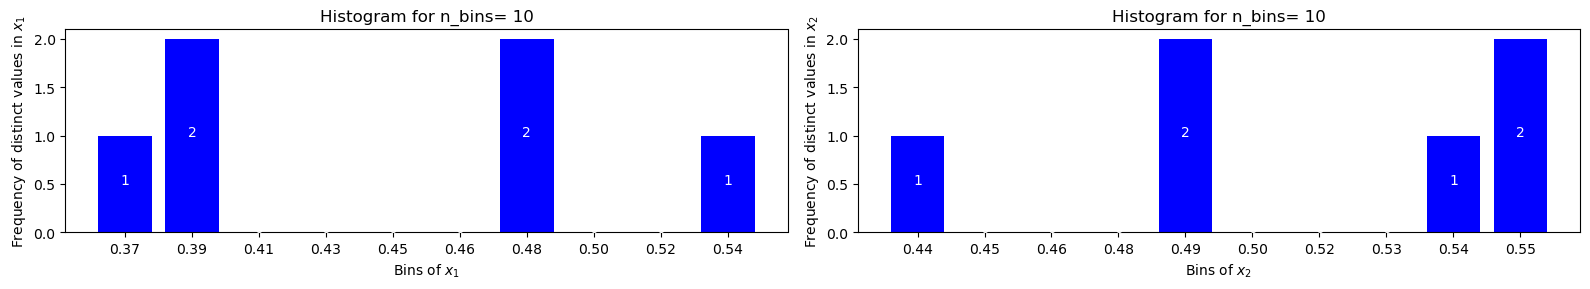

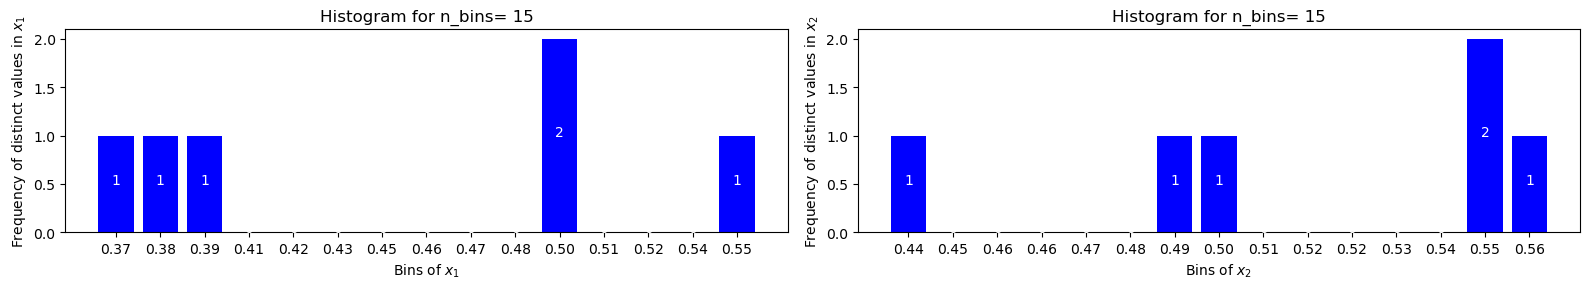

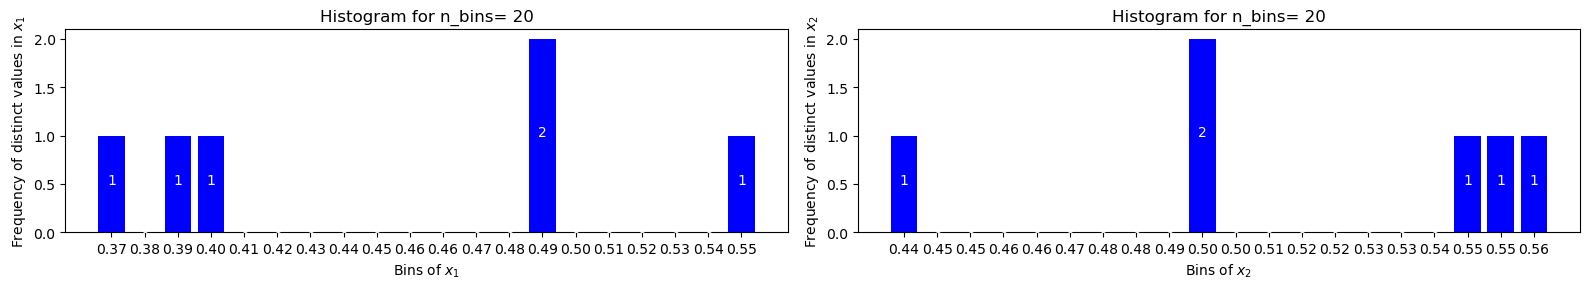

In [158]:
x_hist_pvi= []
y_hist_pvi= []
y_part_pvi= []
x_part_pvi= []
for n_bins in bins_list:
    partition_points = partition_interval(x_min, x_max, n_bins)
    x_part_pvi.append(partition_points)
#     print("Partition points:", partition_points)
    bin_counts = count_values_in_bins(x, partition_points)
    x_hist_pvi.append(bin_counts)
#     bin_counts= get_per(bin_counts)
#     print("Counts in each bin:", bin_counts)

    y_partition_points = partition_interval(y_min, y_max, n_bins)
    y_part_pvi.append(y_partition_points)
    y_bin_counts = count_values_in_bins(y, y_partition_points)
    y_hist_pvi.append(y_bin_counts)
    
#     y_bin_counts= get_per(y_bin_counts)
#     print("Counts in each bin:", y_bin_counts)


    plt.figure(figsize=(16, 3))

    plt.subplot(1, 2, 1)
    bars = plt.bar(range(len(bin_counts)), bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(bin_counts)), ["{:.2f}".format(b) for b in partition_points[:-1]])
    plt.xlabel('Bins of $x_1$')
    plt.ylabel('Frequency of distinct values in $x_1$')
    plt.title('Histogram for n_bins= {}'.format(len(bin_counts)))
#     plt.grid(True)

    plt.subplot(1, 2, 2)
    bars = plt.bar(range(len(y_bin_counts)), y_bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(y_bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(y_bin_counts)), ["{:.2f}".format(b) for b in y_partition_points[:-1]])
    plt.xlabel('Bins of $x_2$')
    plt.ylabel('Frequency of distinct values in $x_2$')
    plt.title('Histogram for n_bins= {}'.format(len(y_bin_counts)))
#     plt.grid(True)
    plt.tight_layout()
#     plt.savefig('../PVI/solns_runs/Ex9/'+'ex9_pvi_hist'+str(n_bins)+'.png')
    plt.show()

## Uniform CDF vs. empirical CDF and KS-Test

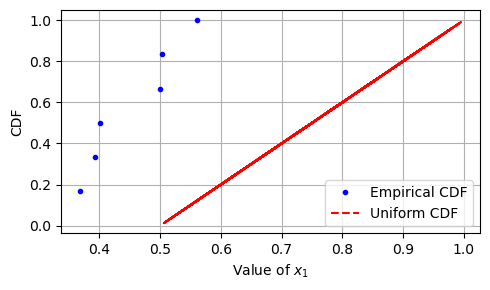

K-S Statistic: 0.43928439429485033
P-Value: 0.14292164203111524
Fail to reject the null hypothesis: The sample follows the uniform distribution.


In [159]:
# KS Test on x: 
a,b= 0.5,1.0
uniform_samples = np.random.uniform(low=a, high=b, size=100)
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

# Number of samples
n_samples = len(xpvi)

# Generate uniform values in [0,1]
#uniform_samples = np.random.uniform(low=0.0, high=1.0, size=n_samples)

# Plotting the histogram of uniform samples
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(xpvi)
ecdf_pvi_x = ECDF(xpvi) #np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_pvi_x.x, ecdf_pvi_x.y, marker='.', linestyle='none', label='Empirical CDF',c= 'blue')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples,cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiric')
plt.xlabel('Value of $x_1$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
#plt.savefig('../PVI/solns_runs/Ex5/ks_ex5_x1.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(xpvi, "uniform")#stats.kstest(ecdf.y, stats.uniform.cdf) #stats.kstest(ecdf.y, cdf_uniform)

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")

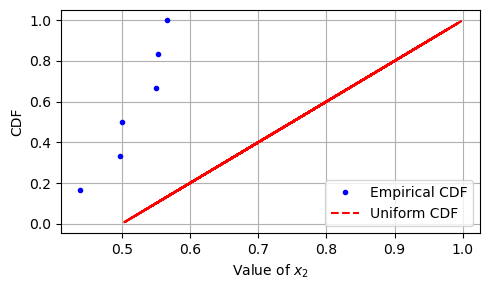

K-S Statistic: 0.4392843942948504
P-Value: 0.1429216420311148
Fail to reject the null hypothesis: The sample follows the uniform distribution.


In [160]:
# KS Test on y: 
# Number of samples
a,b= 0.5, 1.0
uniform_samples = np.random.uniform(low=a, high=b, size=100)
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

n_samples = len(xpvi)
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(ypvi)
ecdf_pvi_y = ECDF(ypvi) # np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_pvi_y.x, ecdf_pvi_y.y, marker='.', linestyle='none', label='Empirical CDF', c= 'blue')
# plt.plot([1-1, 1-0.5], [1-1, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples, cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples')
plt.xlabel('Value of $x_2$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.savefig('../PVI/solns_runs/Ex5/ks_ex5_x2.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(ypvi, "uniform")

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")

### Number of starting points vs. PDP and HD

In [161]:
# folders= ["../PVI/solns_runs/Ex1/T{}/N{}/".format(T,str(pt)) for pt in nubmer_points_list]
# folders
nubmer_points_list= [100, 200,300,400,500,600,700,800,900,1000,1100,1200, 1300,1400,1500]

In [162]:
# pdp, hd= get_values(folders)

# BFGS

In [163]:
def list_subfolders(folder_path):
    subfolders = [f.path for f in os.scandir(folder_path) if f.is_dir()]
    sorted_subfolders = sorted(subfolders, key=lambda x: int(x.split("_")[-1]))
    return sorted_subfolders


def list_txt_files(folder_path):
    txt_files = [f for f in os.listdir(folder_path) if f.endswith('.txt')]
#     txt_files = sorted(|txt_files, key=lambda x: int(x.split("_")[2]))
    return txt_files

### Number of starting points vs. PDP and HD

In [164]:
main_path = "../Merit/solns_runs/Ex10/"
subfolders = list_subfolders(main_path)

    
txt_files = list_subfolders(subfolders[0])
# list_txt_files(subfolders[0])

titles = [str(100*i) for i in range(1, 16)]

colors = [
    'blue', 'orange', 'r', 'yellow', 'purple',
    'brown', 'pink', 'gray', 'olive', 'cyan', 'red',
    'lightcoral', 'darkgoldenrod', 'mediumseagreen', 'green', 'mangeta'
]

folders= ["../Merit/solns_runs/Ex10/N_{}/".format(str(pt)) for pt in nubmer_points_list]
folders

['../Merit/solns_runs/Ex10/N_100/',
 '../Merit/solns_runs/Ex10/N_200/',
 '../Merit/solns_runs/Ex10/N_300/',
 '../Merit/solns_runs/Ex10/N_400/',
 '../Merit/solns_runs/Ex10/N_500/',
 '../Merit/solns_runs/Ex10/N_600/',
 '../Merit/solns_runs/Ex10/N_700/',
 '../Merit/solns_runs/Ex10/N_800/',
 '../Merit/solns_runs/Ex10/N_900/',
 '../Merit/solns_runs/Ex10/N_1000/',
 '../Merit/solns_runs/Ex10/N_1100/',
 '../Merit/solns_runs/Ex10/N_1200/',
 '../Merit/solns_runs/Ex10/N_1300/',
 '../Merit/solns_runs/Ex10/N_1400/',
 '../Merit/solns_runs/Ex10/N_1500/']

In [165]:
def get_values(folders):
    dist_= []
    avg_hd= []
    for pt in range(len(nubmer_points_list)):
        directory_path = folders[pt]

        files= list_txt_files_in_directory(directory_path)
        if len(files)>n_times:
            files= files[:n_times]
        res= []
        hd= []
        
        num_points= nubmer_points_list[pt]
        
        res_solns= []
        for file in files:
            
            if "._" in file:
                    file= file.replace("._","")
            
            solns= np.genfromtxt(file, delimiter=',')
            res_solns.extend(solns.tolist())
        
        
        res_solns= np.array(res_solns)
        num, distinct_points= count_repeated_points(res_solns)
        distinct_points= np.array(distinct_points)
        
        # Get PDP
        
        dist_.append((len(distinct_points)/(len(res_solns)))*100)
        
        # Get HD:
        
        x2= np.random.uniform(0.0, 3/4, len(distinct_points))
        x1= np.array([get_x1(i) for i in x2])
        points= np.concatenate((x1.reshape(-1,1),x2.reshape(-1,1)),1)


        

        print(len(distinct_points),len(res_solns))
        hausdorff_distance = directed_hausdorff(distinct_points, points)[0]
        avg_hd.append(hausdorff_distance)
        
    # Create subplots with different scales
    fig, ax1 = plt.subplots(figsize=(8, 4))

    # Create second axis with different scale
    ax1.set_xlabel('Number of starting points')
#     ax2 = ax1.twinx()
    ax1.set_ylim([0.0, np.max(dist_)])
    ax1.plot(nubmer_points_list, dist_, 'bo-')
    
#     ax1.set_yticks(dist_)
    
    ax1.set_ylabel('Perentage of distint points',color='blue')
#     ax1.set_ylabel('Perentage of distint points', color='b')


    # Create third axis with different scale
    ax2 = ax1.twinx()
    ax2.spines['right'].set_position(('outward', 60))  # Move the spine to the right
    ax2.plot(nubmer_points_list, avg_hd, 'go-')
    ax2.set_ylabel('Hausdorff Distance', color='g')
    ax2.set_ylim([0.0, np.max(avg_hd)])

    xticks = nubmer_points_list  # Precisely specify xticks from 0 to 10 with a step of 1
    ax1.set_xticks(xticks)
    ax1.set_xticklabels([f'{tick:.0f}' for tick in xticks])  # Format labels as strings with one decimal place


#     plt.savefig('./plots/Metrics/Ex1/ex1_gsm.jpeg')
    plt.savefig('../Merit/solns_runs/Ex10/plot_ex10.png')
# plt.xticks(list(range(len(possible_num_points))),possible_num_points)
    plt.grid(True)
    plt.show()

        
    return dist_,avg_hd

152 1000
297 2000
440 3000
623 4000
776 5000
904 6000
1042 7000
1187 8000
1328 9000
1547 10000
1668 11000
1805 12000
2041 13000
2126 14000
2277 15000


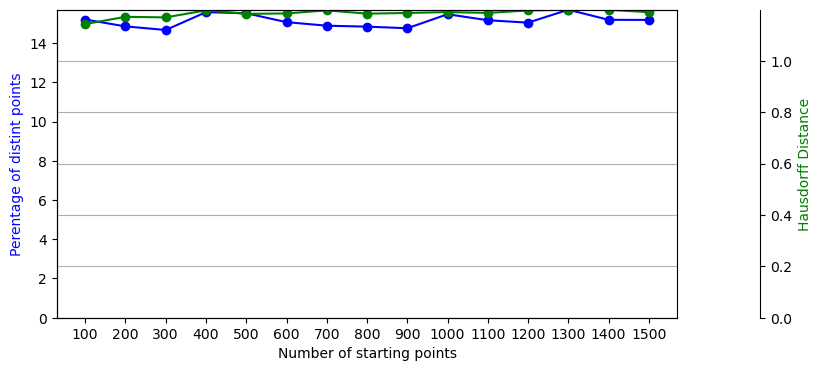

In [166]:
pdpbfgs, hdbfgs= get_values(folders)

In [167]:
for (p,h) in zip(pdpbfgs,hdbfgs):
    print(p, " * ", h)

15.2  *  1.1436737803761559
14.85  *  1.1718395582956274
14.666666666666666  *  1.1695978792642905
15.575  *  1.197099225199351
15.52  *  1.183377278333574
15.066666666666666  *  1.1850000192226406
14.885714285714286  *  1.1969113284985646
14.8375  *  1.1842104950347634
14.755555555555555  *  1.1868935420786637
15.47  *  1.1902461407788194
15.163636363636362  *  1.1871576573719584
15.041666666666668  *  1.196655329370189
15.7  *  1.1994944797315905
15.185714285714285  *  1.1993001160545296
15.18  *  1.1897089914275114


In [168]:
max(pdpbfgs), min(hdbfgs)

(15.7, 1.1436737803761559)

In [169]:
# plot_solns(folders)

In [170]:
nubmer_points_list[np.argmax(pdpbfgs)]

1300

### Histograms

In [171]:
# n_runs= 50 and 
n_points= nubmer_points_list[np.argmax(pdpbfgs)]
# Best
directory_path = "../Merit/solns_runs/Ex10/N_{}".format(n_points)
all_solnsbfgs= []

files= list_txt_files_in_directory(directory_path)
if len(files)>n_times:
    files= files[:n_times]
for file in files:
    if "._" in file:
        file= file.replace("._","")
    solns= np.genfromtxt(file, delimiter=',')

#     num, distinct_points = count_repeated_points(solns)
#     distinct_points= np.array(distinct_points)
    all_solnsbfgs.extend(solns.tolist())


#all_solnsbfgs = [point for point in all_solnsbfgs if point[0] >= 0 and point[1] >= 0]

all_solnsbfgs= np.array(all_solnsbfgs)
num, all_solnsbfgs = count_repeated_points(all_solnsbfgs)
all_solnsbfgs= np.array(all_solnsbfgs)

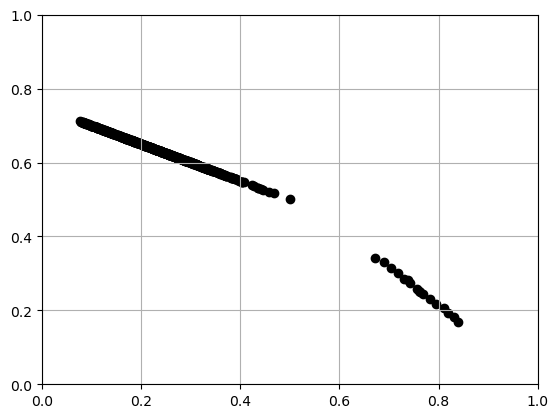

In [172]:
plt.scatter(all_solnsbfgs[:,0], all_solnsbfgs[:,1], c= 'black')
plt.xlim([0,1.0])
plt.ylim([0,1.0])
plt.grid(True)
plt.show()

In [173]:
num

2041

In [174]:
## x:
bins_list= [5,10,15,20]
solns= all_solnsbfgs.copy()


## y:
y=  solns[:,1]
y= [i for i in y if i != None]

y_min = np.min(y)
y_max = np.max(y)

x= np.array([get_x1(i) for i in y])
x= [[i,j] for (i,j) in zip(x,y) if i != None]
x= np.array(x)
# print(x)
y= x[:,1]
x= x[:,0]

x_min = np.min(x)
print(len(y), len(x))
x_max = np.max(x)

# # y

xbfgs= x.copy()
ybfgs= y.copy()

625 625


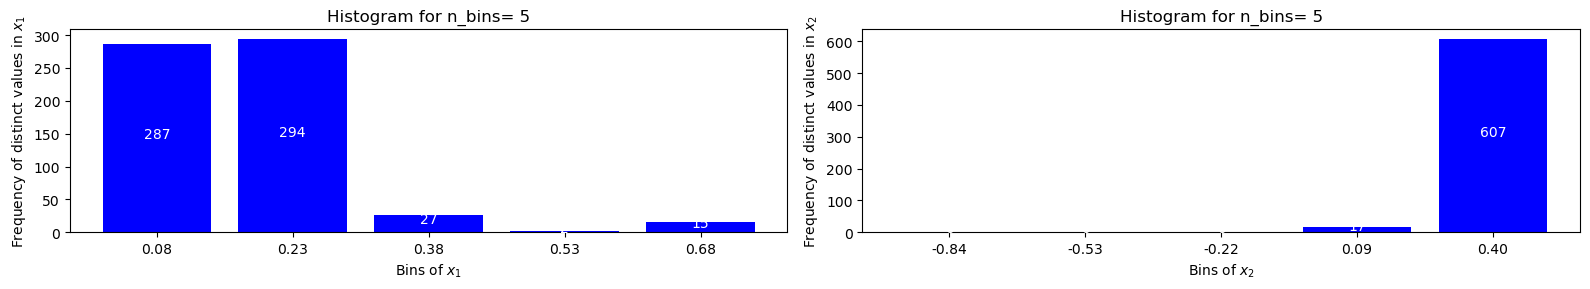

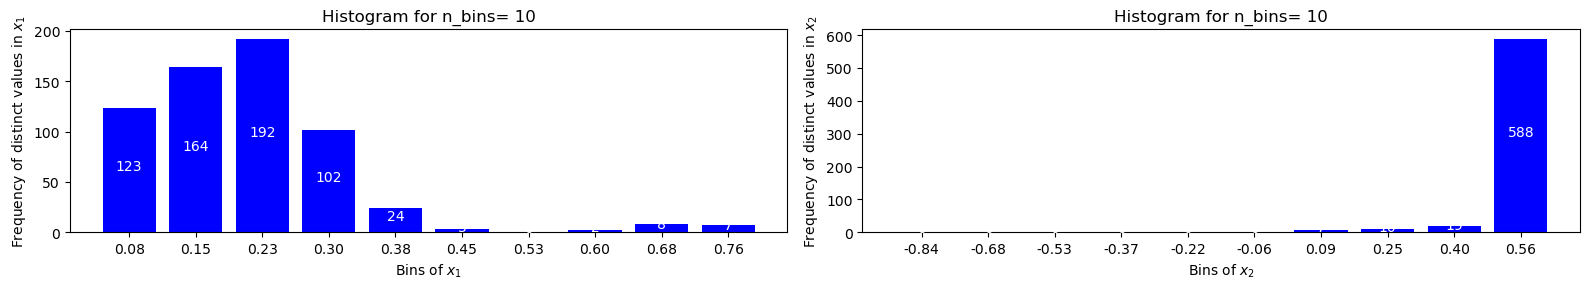

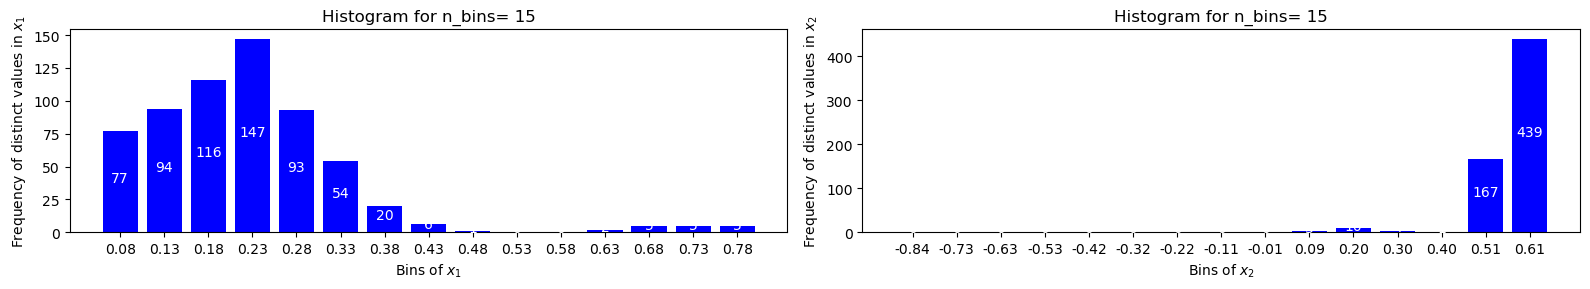

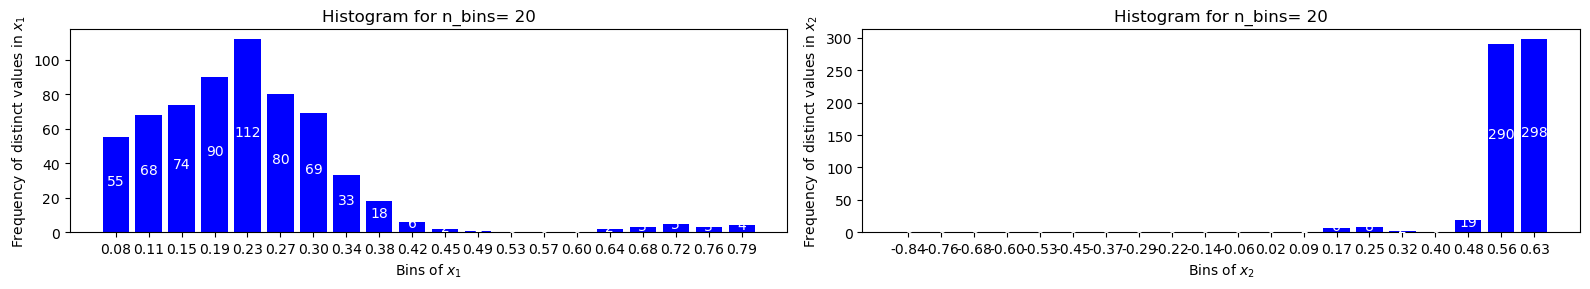

In [175]:
x_hist_bfgs= []
y_hist_bfgs= []
y_part_bfgs= []
x_part_bfgs= []
for n_bins in bins_list:
    partition_points = partition_interval(x_min, x_max, n_bins)
    x_part_bfgs.append(partition_points)
#     print("Partition points:", partition_points)
    bin_counts = count_values_in_bins(x, partition_points)
    x_hist_bfgs.append(bin_counts)
#     bin_counts= get_per(bin_counts)
#     print("Counts in each bin:", bin_counts)

    y_partition_points = partition_interval(y_min, y_max, n_bins)
    y_part_bfgs.append(y_partition_points)
    y_bin_counts = count_values_in_bins(y, y_partition_points)
    y_hist_bfgs.append(y_bin_counts)
    
#     y_bin_counts= get_per(y_bin_counts)
#     print("Counts in each bin:", y_bin_counts)


    plt.figure(figsize=(16, 3))

    plt.subplot(1, 2, 1)
    bars = plt.bar(range(len(bin_counts)), bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(bin_counts)), ["{:.2f}".format(b) for b in partition_points[:-1]])
    plt.xlabel('Bins of $x_1$')
    plt.ylabel('Frequency of distinct values in $x_1$')
    plt.title('Histogram for n_bins= {}'.format(len(bin_counts)))
#     plt.grid(True)

    plt.subplot(1, 2, 2)
    bars = plt.bar(range(len(y_bin_counts)), y_bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(y_bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(y_bin_counts)), ["{:.2f}".format(b) for b in y_partition_points[:-1]])
    plt.xlabel('Bins of $x_2$')
    plt.ylabel('Frequency of distinct values in $x_2$')
    plt.title('Histogram for n_bins= {}'.format(len(y_bin_counts)))
#     plt.grid(True)
    plt.tight_layout()
    plt.savefig('../Merit/solns_runs/Ex10/'+'ex10_bfgs_hist'+str(n_bins)+'.png')
    plt.show()

### Uniform CDF vs. empirical CDF and KS-Test

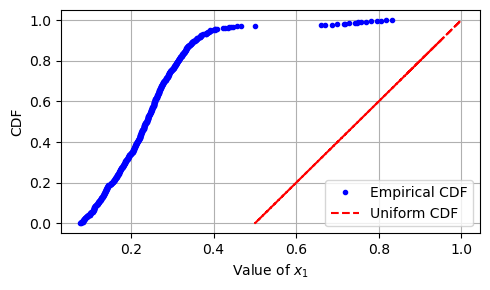

K-S Statistic: 0.5586351933061587
P-Value: 3.176621982409923e-184
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [176]:
 # KS Test on x: 
a,b= 0.5,1.0
uniform_samples = np.random.uniform(low=a, high=b, size=len(x))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

# Number of samples
n_samples = len(xbfgs)

# Generate uniform values in [0,1]
#uniform_samples = np.random.uniform(low=0.0, high=1.0, size=n_samples)

# Plotting the histogram of uniform samples
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(xbfgs)
ecdf_bfgs_x = ECDF(xbfgs) #np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_bfgs_x.x, ecdf_bfgs_x.y, marker='.', linestyle='none', label='Empirical CDF',c= 'blue')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples,cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiric')
plt.xlabel('Value of $x_1$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../Merit/solns_runs/Ex10/ks_ex10_x1.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(xbfgs, "uniform")#stats.kstest(ecdf.y, stats.uniform.cdf) #stats.kstest(ecdf.y, cdf_uniform)

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")

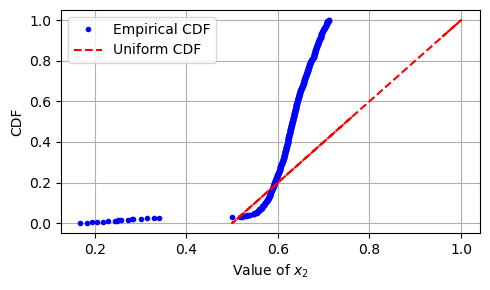

K-S Statistic: 0.5045830288340518
P-Value: 7.291870706828221e-148
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [177]:
# KS Test on y: 
# Number of samples
a,b= 0.5, 1.0
uniform_samples = np.random.uniform(low=a, high=b, size=len(x))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

n_samples = len(ybfgs)
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(ybfgs)
ecdf_bfgs_y = ECDF(ybfgs) # np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_bfgs_y.x, ecdf_bfgs_y.y, marker='.', linestyle='none', label='Empirical CDF', c= 'blue')
# plt.plot([1-1, 1-0.5], [1-1, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples, cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples')
plt.xlabel('Value of $x_2$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../Merit/solns_runs/Ex10/ks_ex10_x2.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(ybfgs, "uniform")

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")

# EIA

## Number of starting points vs. PDP and HD

In [178]:
main_path = "../EIA/solns_runs/Ex10/"
subfolders = list_subfolders(main_path)

    
txt_files = list_subfolders(subfolders[0])
# list_txt_files(subfolders[0])

titles = [str(100*i) for i in range(1, 16)]

colors = [
    'blue', 'orange', 'r', 'yellow', 'purple',
    'brown', 'pink', 'gray', 'olive', 'cyan', 'red',
    'lightcoral', 'darkgoldenrod', 'mediumseagreen', 'green', 'mangeta'
]

folders= ["../EIA/solns_runs/Ex10/N_{}/".format(str(pt)) for pt in nubmer_points_list]
folders

['../EIA/solns_runs/Ex10/N_100/',
 '../EIA/solns_runs/Ex10/N_200/',
 '../EIA/solns_runs/Ex10/N_300/',
 '../EIA/solns_runs/Ex10/N_400/',
 '../EIA/solns_runs/Ex10/N_500/',
 '../EIA/solns_runs/Ex10/N_600/',
 '../EIA/solns_runs/Ex10/N_700/',
 '../EIA/solns_runs/Ex10/N_800/',
 '../EIA/solns_runs/Ex10/N_900/',
 '../EIA/solns_runs/Ex10/N_1000/',
 '../EIA/solns_runs/Ex10/N_1100/',
 '../EIA/solns_runs/Ex10/N_1200/',
 '../EIA/solns_runs/Ex10/N_1300/',
 '../EIA/solns_runs/Ex10/N_1400/',
 '../EIA/solns_runs/Ex10/N_1500/']

In [179]:
def get_values(folders):
    dist_= []
    avg_hd= []
    for pt in range(len(nubmer_points_list)):
        directory_path = folders[pt]

        files= list_txt_files_in_directory(directory_path)
        if len(files)>n_times:
            files= files[:n_times]
        res= []
        hd= []
        
        num_points= nubmer_points_list[pt]
        
        res_solns= []
        for file in files:
            
            if "._" in file:
                    file= file.replace("._","")
            
            solns= np.genfromtxt(file, delimiter=',')
            #solns = [point for point in solns if point[0] >= 0 and point[1] >= 0]
            #solns= np.array(solns)
            res_solns.extend(solns.tolist())
        
        
        res_solns= np.array(res_solns)
        num, distinct_points= count_repeated_points(res_solns)
        distinct_points= np.array(distinct_points)
        
        # Get PDP
        
        dist_.append((len(distinct_points)/(len(res_solns)))*100)
        
        # Get HD:
        
        x2= np.random.uniform(0.0, 3/4, len(distinct_points))
        x1= np.array([get_x1(i) for i in x2])
        points= np.concatenate((x1.reshape(-1,1),x2.reshape(-1,1)),1)


        

        print(len(distinct_points),len(res_solns))
        hausdorff_distance = directed_hausdorff(distinct_points, points)[0]
        avg_hd.append(hausdorff_distance)
        
    # Create subplots with different scales
    fig, ax1 = plt.subplots(figsize=(8, 4))

    # Create second axis with different scale
    ax1.set_xlabel('Number of starting points')
#     ax2 = ax1.twinx()
    ax1.set_ylim([0.0, np.max(dist_)])
    ax1.plot(nubmer_points_list, dist_, 'bo-')
    
#     ax1.set_yticks(dist_)
    
    ax1.set_ylabel('Perentage of distint points',color='blue')
#     ax1.set_ylabel('Perentage of distint points', color='b')


    # Create third axis with different scale
    ax2 = ax1.twinx()
    ax2.spines['right'].set_position(('outward', 60))  # Move the spine to the right
    ax2.plot(nubmer_points_list, avg_hd, 'go-')
    ax2.set_ylabel('Hausdorff Distance', color='g')
    ax2.set_ylim([0.0, np.max(avg_hd)])

    xticks = nubmer_points_list  # Precisely specify xticks from 0 to 10 with a step of 1
    ax1.set_xticks(xticks)
    ax1.set_xticklabels([f'{tick:.0f}' for tick in xticks])  # Format labels as strings with one decimal place


#     plt.savefig('./plots/Metrics/Ex1/ex1_gsm.jpeg')
    plt.savefig('../EIA/solns_runs/Ex10/plot_ex10.png')
# plt.xticks(list(range(len(possible_num_points))),possible_num_points)
    plt.grid(True)
    plt.show()

        
    return dist_,avg_hd

435 1000
1025 2000
1566 3000
2150 4000
2642 5000
3243 6000
3817 7000
4344 8000
4923 9000
5549 10000
6157 11000
6668 12000
7210 13000
7707 14000
8405 15000


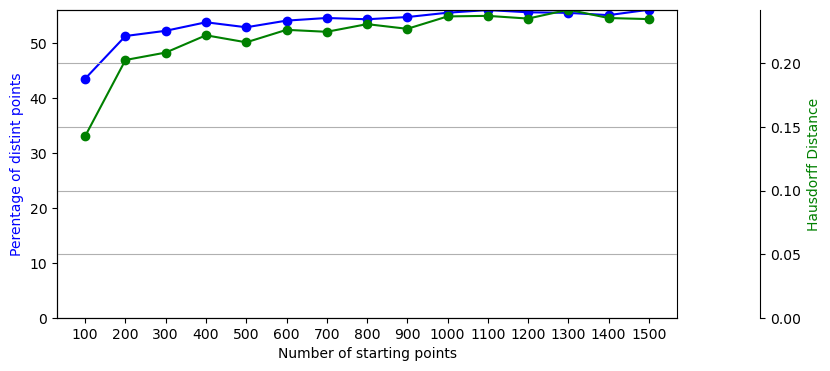

In [180]:
pdpeia, hdeia= get_values(folders)

In [181]:
for (p,h) in zip(pdpeia,hdeia):
    print(p, " * ", h)

43.5  *  0.14280464823824995
51.24999999999999  *  0.20259115426808644
52.2  *  0.2084375188866924
53.75  *  0.22202485226432203
52.839999999999996  *  0.2164740834336845
54.05  *  0.22630639582582626
54.528571428571425  *  0.2247564940832845
54.300000000000004  *  0.2307813446395473
54.7  *  0.22709660766274972
55.489999999999995  *  0.23685352524581388
55.972727272727276  *  0.2372827830101844
55.56666666666666  *  0.23515663396758305
55.46153846153846  *  0.24211285373040697
55.05  *  0.23558872583012525
56.03333333333333  *  0.23474434445351894


In [182]:
max(pdpeia), min(hdeia)

(56.03333333333333, 0.14280464823824995)

In [183]:
#plot_solns(folders)

In [184]:
nubmer_points_list[np.argmax(pdpeia)]

1500

### Histograms

In [185]:
# n_runs= 50 and 
n_points= nubmer_points_list[np.argmax(pdpeia)]
# Best
directory_path = "../EIA/solns_runs/Ex10/N_{}".format(n_points)
all_solnseia= []

files= list_txt_files_in_directory(directory_path)
if len(files)>n_times:
    files= files[:n_times]
for file in files:
    if "._" in file:
        file= file.replace("._","")
    solns= np.genfromtxt(file, delimiter=',')

#     num, distinct_points = count_repeated_points(solns)
#     distinct_points= np.array(distinct_points)
    all_solnseia.extend(solns.tolist())

# all_solnseia = [point for point in all_solnseia if point[0] >= 0 and point[1] >= 0]

all_solnseia= np.array(all_solnseia)
_,all_solnseia= count_repeated_points(all_solnseia)
all_solnseia= np.array(all_solnseia)

In [186]:
# plt.scatter(all_solnseia[:,0], all_solnseia[:,1], c= 'black')
# plt.xlim([0,1.0])
# plt.ylim([0,1.0])
# plt.grid(True)
# plt.show()

In [187]:
## x:
bins_list= [5,10,15,20]
solns= all_solnseia.copy()


## y:
y=  solns[:,1]
y= [i for i in y if i != None]

y_min = np.min(y)
y_max = np.max(y)

x= np.array([get_x1(i) for i in y])
x= [[i,j] for (i,j) in zip(x,y) if i != None]
x= np.array(x)
# print(x)
y= x[:,1]
x= x[:,0]

x_min = np.min(x)
print(len(y), len(x))
x_max = np.max(x)

# # y

xeia= x.copy()
yeia= y.copy()

6373 6373


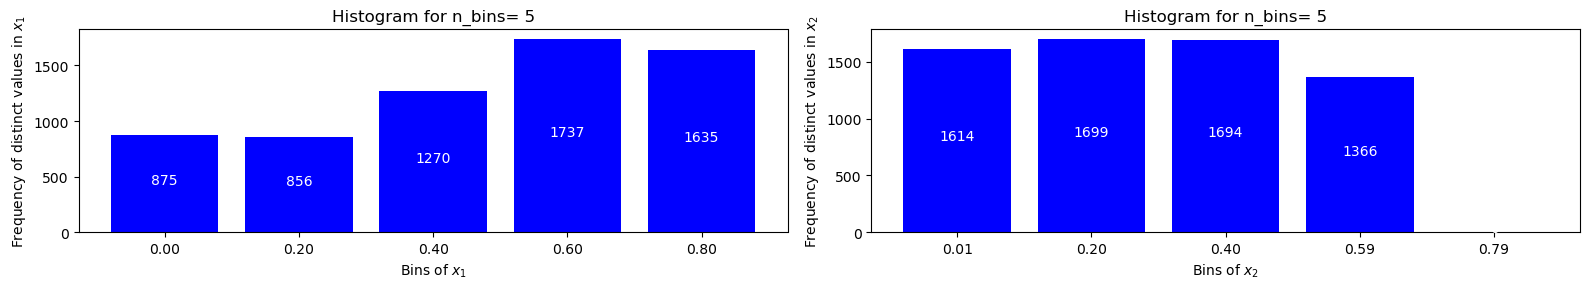

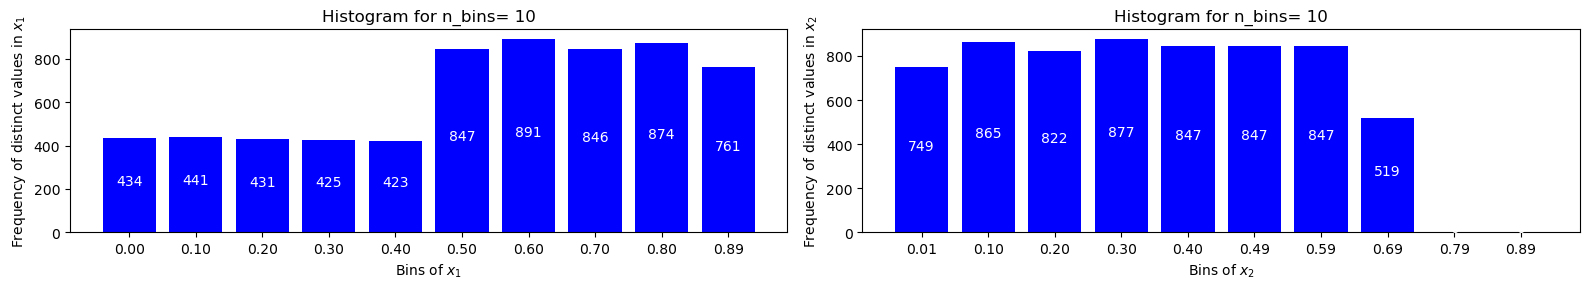

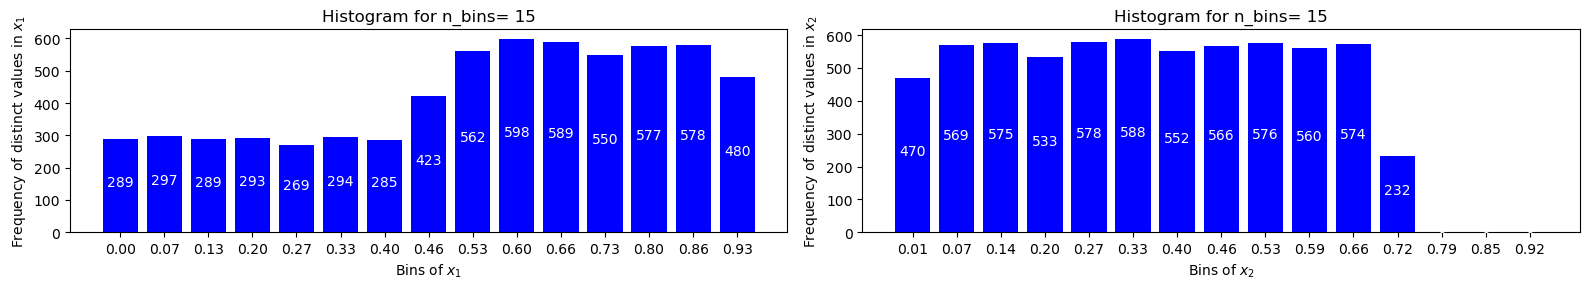

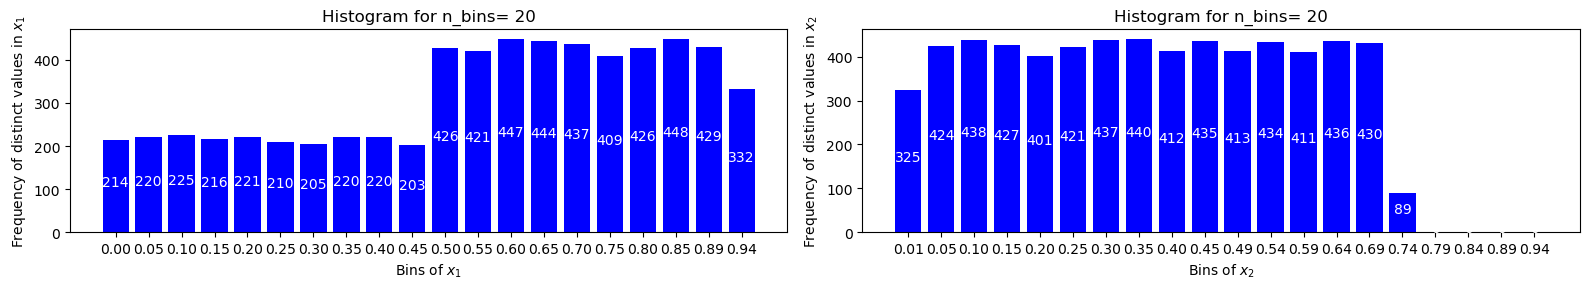

In [188]:
x_hist_eia= []
y_hist_eia= []
y_part_eia= []
x_part_eia= []
for n_bins in bins_list:
    partition_points = partition_interval(x_min, x_max, n_bins)
    x_part_eia.append(partition_points)
#     print("Partition points:", partition_points)
    bin_counts = count_values_in_bins(x, partition_points)
    x_hist_eia.append(bin_counts)
#     bin_counts= get_per(bin_counts)
#     print("Counts in each bin:", bin_counts)

    y_partition_points = partition_interval(y_min, y_max, n_bins)
    y_part_eia.append(y_partition_points)
    y_bin_counts = count_values_in_bins(y, y_partition_points)
    y_hist_eia.append(y_bin_counts)
    
#     y_bin_counts= get_per(y_bin_counts)
#     print("Counts in each bin:", y_bin_counts)


    plt.figure(figsize=(16, 3))

    plt.subplot(1, 2, 1)
    bars = plt.bar(range(len(bin_counts)), bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(bin_counts)), ["{:.2f}".format(b) for b in partition_points[:-1]])
    plt.xlabel('Bins of $x_1$')
    plt.ylabel('Frequency of distinct values in $x_1$')
    plt.title('Histogram for n_bins= {}'.format(len(bin_counts)))
#     plt.grid(True)

    plt.subplot(1, 2, 2)
    bars = plt.bar(range(len(y_bin_counts)), y_bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(y_bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(y_bin_counts)), ["{:.2f}".format(b) for b in y_partition_points[:-1]])
    plt.xlabel('Bins of $x_2$')
    plt.ylabel('Frequency of distinct values in $x_2$')
    plt.title('Histogram for n_bins= {}'.format(len(y_bin_counts)))
#     plt.grid(True)
    plt.tight_layout()
    plt.savefig('../EIA/solns_runs/Ex10/'+'ex10_eia_hist'+str(n_bins)+'.png')
    plt.show()

### Uniform CDF vs. empirical CDF and  KS-Test

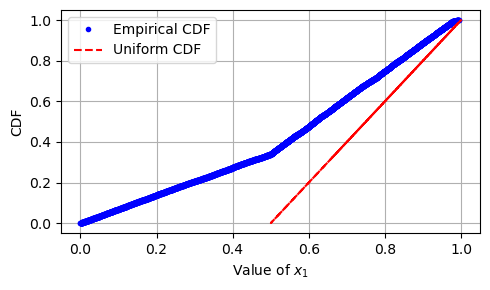

K-S Statistic: 0.1603521046084464
P-Value: 1.2617641197914856e-143
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [189]:
# KS Test on x: 
a,b= 0.5,1.0
uniform_samples = np.random.uniform(low=a, high=b, size=len(xeia))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

# Number of samples
n_samples = len(xeia)

# Generate uniform values in [0,1]
#uniform_samples = np.random.uniform(low=0.0, high=1.0, size=n_samples)

# Plotting the histogram of uniform samples
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(xeia)
ecdf_eia_x = ECDF(xeia) #np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_eia_x.x, ecdf_eia_x.y, marker='.', linestyle='none', label='Empirical CDF',c= 'blue')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples,cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiric')
plt.xlabel('Value of $x_1$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../EIA/solns_runs/Ex10/ks_ex10_x1.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(xeia, "uniform")#stats.kstest(ecdf.y, stats.uniform.cdf) #stats.kstest(ecdf.y, cdf_uniform)

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.") 

In [190]:
ks_statistic,p_value

(0.1603521046084464, 1.2617641197914856e-143)

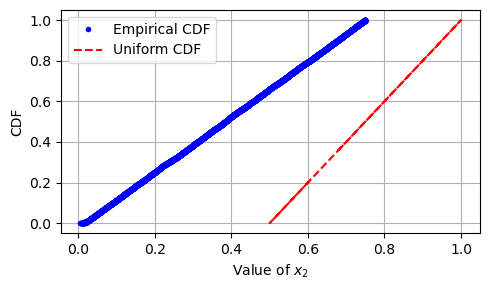

K-S Statistic: 0.2500373485749836
P-Value: 0.0
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [191]:
# KS Test on y: 
# Number of samples
a,b= 0.5, 1.0
uniform_samples = np.random.uniform(low=a, high=b, size=len(xeia))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

n_samples = len(yeia)
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(yeia)
ecdf_eia_y = ECDF(yeia) # np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_eia_y.x, ecdf_eia_y.y, marker='.', linestyle='none', label='Empirical CDF', c= 'blue')
# plt.plot([1-1, 1-0.5], [1-1, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples, cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples')
plt.xlabel('Value of $x_2$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../EIA/solns_runs/Ex10/ks_ex10_x2.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(yeia, "uniform")

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")

# SGD (one run with 100 points)

In [192]:
nubmer_points_list= [100, 200,300,400,500,600,700,800,900,1000,1100,1200, 1300,1400,1500]
#nubmer_points_list= nubmer_points_list[:13]

In [193]:
main_path = "../SGD/solns_runs/Ex10/"
subfolders = list_subfolders(main_path)

    
txt_files = list_subfolders(subfolders[0])
# list_txt_files(subfolders[0])

titles = [str(100*i) for i in range(1, 16)]

colors = [
    'blue', 'orange', 'r', 'yellow', 'purple',
    'brown', 'pink', 'gray', 'olive', 'cyan', 'red',
    'lightcoral', 'darkgoldenrod', 'mediumseagreen', 'green', 'mangeta'
]

folders= ["../SGD/solns_runs/Ex10/N_{}/".format(str(pt)) for pt in nubmer_points_list]
folders

['../SGD/solns_runs/Ex10/N_100/',
 '../SGD/solns_runs/Ex10/N_200/',
 '../SGD/solns_runs/Ex10/N_300/',
 '../SGD/solns_runs/Ex10/N_400/',
 '../SGD/solns_runs/Ex10/N_500/',
 '../SGD/solns_runs/Ex10/N_600/',
 '../SGD/solns_runs/Ex10/N_700/',
 '../SGD/solns_runs/Ex10/N_800/',
 '../SGD/solns_runs/Ex10/N_900/',
 '../SGD/solns_runs/Ex10/N_1000/',
 '../SGD/solns_runs/Ex10/N_1100/',
 '../SGD/solns_runs/Ex10/N_1200/',
 '../SGD/solns_runs/Ex10/N_1300/',
 '../SGD/solns_runs/Ex10/N_1400/',
 '../SGD/solns_runs/Ex10/N_1500/']

In [194]:
def get_values(folders):
    dist_= []
    avg_hd= []
    for pt in range(len(nubmer_points_list)):
        directory_path = folders[pt]

        files= list_txt_files_in_directory(directory_path)
        if len(files)>n_times:
            files= files[:n_times]
        res= []
        hd= []
        
        num_points= nubmer_points_list[pt]
        
        res_solns= []
        for file in files:
            
            if "._" in file:
                    file= file.replace("._","")
            
            solns= np.genfromtxt(file, delimiter=',')[:,:-1]
            #mask= solns[:,-1]<=0.01
            #solns= solns[mask][:,:-1]
            res_solns.extend(solns.tolist())
        
        
        res_solns= np.array(res_solns)
        num, distinct_points= count_repeated_points(res_solns)
        distinct_points= np.array(distinct_points)
        
        # Get PDP
        
        dist_.append((len(distinct_points)/(len(res_solns)))*100)
        
        # Get HD:
        
        x2= np.random.uniform(0.0, 3/4, len(distinct_points))
        x1= np.array([get_x1(i) for i in x2])
        points= np.concatenate((x1.reshape(-1,1),x2.reshape(-1,1)),1)


        

        print(len(distinct_points),len(res_solns))
        hausdorff_distance = directed_hausdorff(distinct_points, points)[0]
        avg_hd.append(hausdorff_distance)
        
    # Create subplots with different scales
    fig, ax1 = plt.subplots(figsize=(8, 4))

    # Create second axis with different scale
    ax1.set_xlabel('Number of starting points')
#     ax2 = ax1.twinx()
    ax1.set_ylim([0.0, np.max(dist_)])
    ax1.plot(nubmer_points_list, dist_, 'bo-')
    
#     ax1.set_yticks(dist_)
    
    ax1.set_ylabel('Perentage of distint points',color='blue')
#     ax1.set_ylabel('Perentage of distint points', color='b')


    # Create third axis with different scale
    ax2 = ax1.twinx()
    ax2.spines['right'].set_position(('outward', 60))  # Move the spine to the right
    ax2.plot(nubmer_points_list, avg_hd, 'go-')
    ax2.set_ylabel('Hausdorff Distance', color='g')
    ax2.set_ylim([0.0, np.max(avg_hd)])

    xticks = nubmer_points_list  # Precisely specify xticks from 0 to 10 with a step of 1
    ax1.set_xticks(xticks)
    ax1.set_xticklabels([f'{tick:.0f}' for tick in xticks])  # Format labels as strings with one decimal place


#     plt.savefig('./plots/Metrics/Ex1/ex1_gsm.jpeg')
    plt.savefig('../SGD/solns_runs/Ex10/plot_ex10.png')
# plt.xticks(list(range(len(possible_num_points))),possible_num_points)
    plt.grid(True)
    plt.show()

        
    return dist_,avg_hd

509 1000
1115 2000
1895 3000
2661 4000
3509 5000
4380 6000
5286 7000
6232 8000
7131 9000
8051 10000
9096 11000
10045 12000
11006 13000
12021 14000
13019 15000


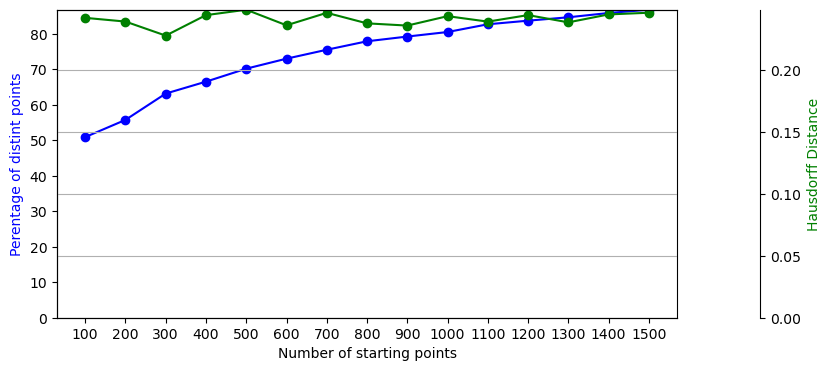

In [195]:
pdpsgd, hdsgd= get_values(folders)

In [196]:
for (p,h) in zip(pdpsgd,hdsgd):
    print(p, " * ", h)

50.9  *  0.2425178241727777
55.75  *  0.2395058908752995
63.16666666666667  *  0.22814533222701638
66.525  *  0.2447172640293984
70.17999999999999  *  0.24909009903621038
73.0  *  0.23650352400005137
75.5142857142857  *  0.2465811615206194
77.9  *  0.23806488814275154
79.23333333333333  *  0.2362661815403471
80.51  *  0.2438734451567033
82.69090909090909  *  0.2394676172533509
83.70833333333333  *  0.24474374444469635
84.66153846153847  *  0.23887120327035458
85.86428571428571  *  0.24528672763365272
86.79333333333334  *  0.2466582883201926


In [197]:
max(pdpsgd), min(hdsgd)

(86.79333333333334, 0.22814533222701638)

## Histograms

In [198]:
nubmer_points_list[np.argmax(pdpsgd)]

1500

In [199]:
n_points= nubmer_points_list[np.argmax(pdpsgd)]
# Best
directory_path = "../SGD/solns_runs/Ex10/N_{}".format(n_points)
all_solnssgd= []

files= list_txt_files_in_directory(directory_path)
if len(files)>n_times:
    files= files[:n_times]
for file in files:
    if "._" in file:
        file= file.replace("._","")
    solns= np.genfromtxt(file, delimiter=',')[:,:-1]
    #mask= solns[:,-1]<2.5
    #solns= solns[mask]
#     num, distinct_points = count_repeated_points(solns)
#     distinct_points= np.array(distinct_points)
    
    all_solnssgd.extend(solns.tolist())


all_solnssgd= np.array(all_solnssgd)

num, all_solnssgd = count_repeated_points(all_solnssgd)
all_solnssgd= np.array(all_solnssgd)
all_solnssgd

array([[0.22360961, 0.77638854],
       [0.60696061, 0.39277542],
       [0.45627157, 0.54393787],
       ...,
       [0.13446869, 0.86529265],
       [0.70131176, 0.29868317],
       [0.35325873, 0.64728855]])

In [200]:
all_solnssgd.shape

(13019, 2)

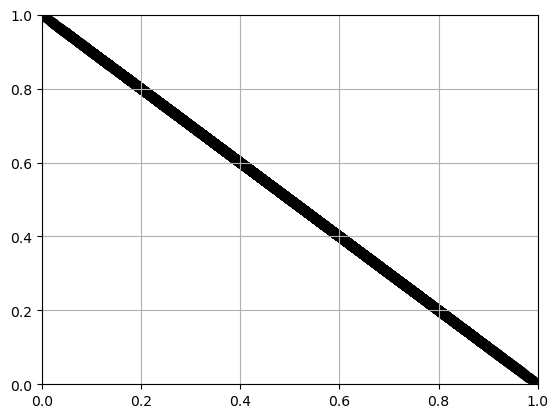

In [201]:
plt.scatter(all_solnssgd[:,0], all_solnssgd[:,1], c= 'black')
plt.xlim([0,1.0])
plt.ylim([0,1.0])
plt.grid(True)
plt.show()

In [202]:
len(all_solnssgd)

13019

In [203]:
## x:
bins_list= [5,10,15,20]
solns= all_solnssgd.copy()


## y:
y=  solns[:,1]
y= [i for i in y if i != None]

y_min = np.min(y)
y_max = np.max(y)

x= np.array([get_x1(i) for i in y])
x= [[i,j] for (i,j) in zip(x,y) if i != None]
x= np.array(x)
# print(x)
y= x[:,1]
x= x[:,0]

x_min = np.min(x)
print(len(y), len(x))
x_max = np.max(x)

# # y

xsgd= x.copy()
ysgd= y.copy()

11255 11255


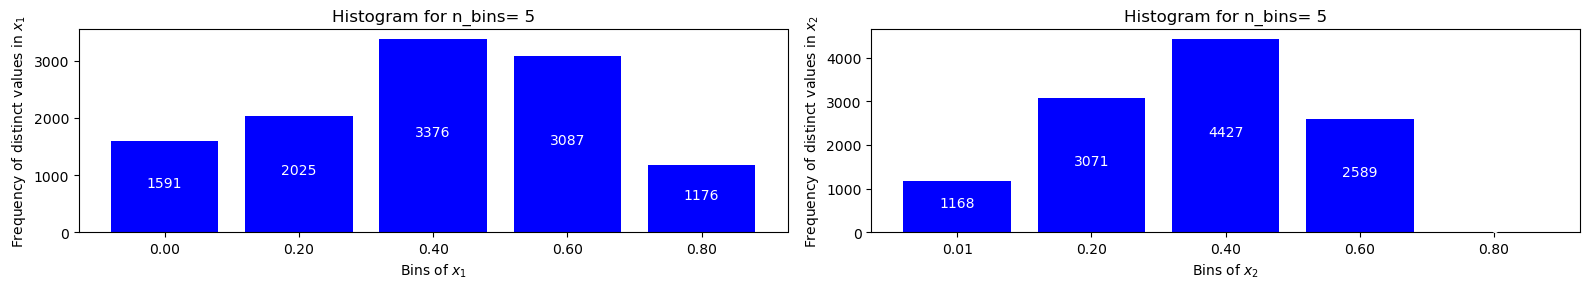

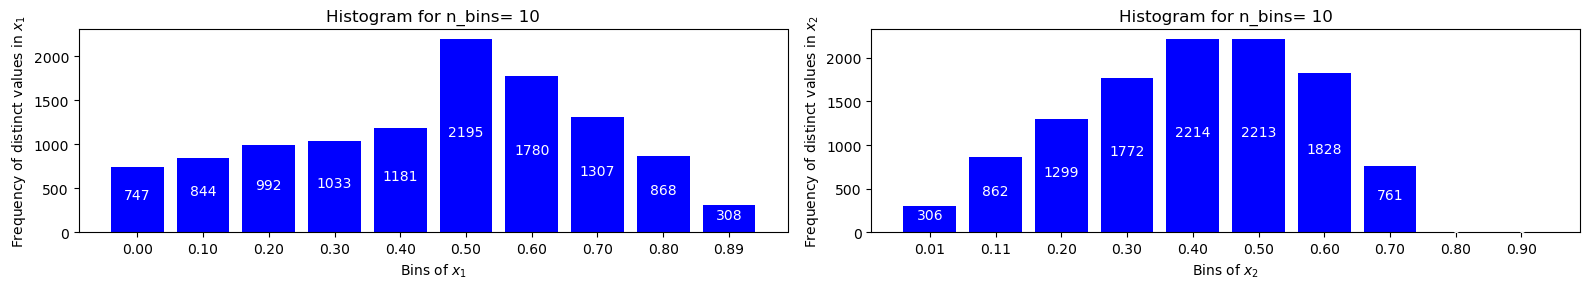

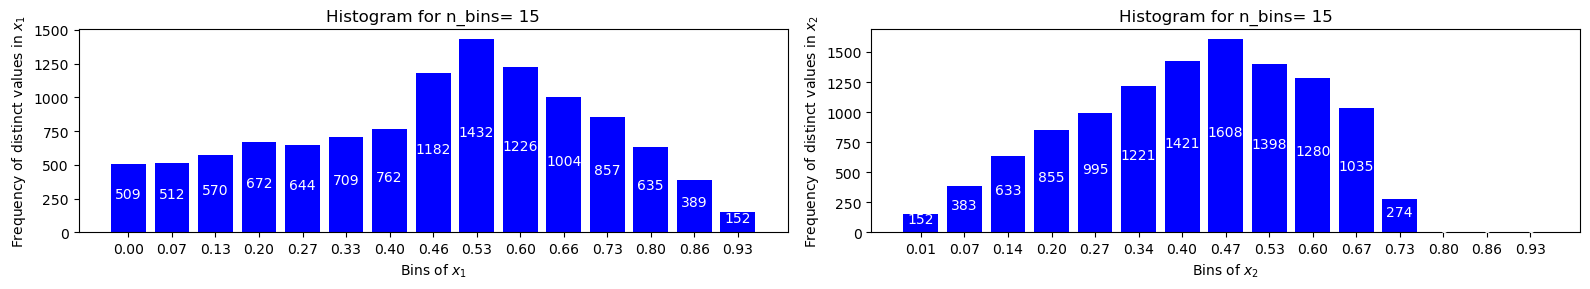

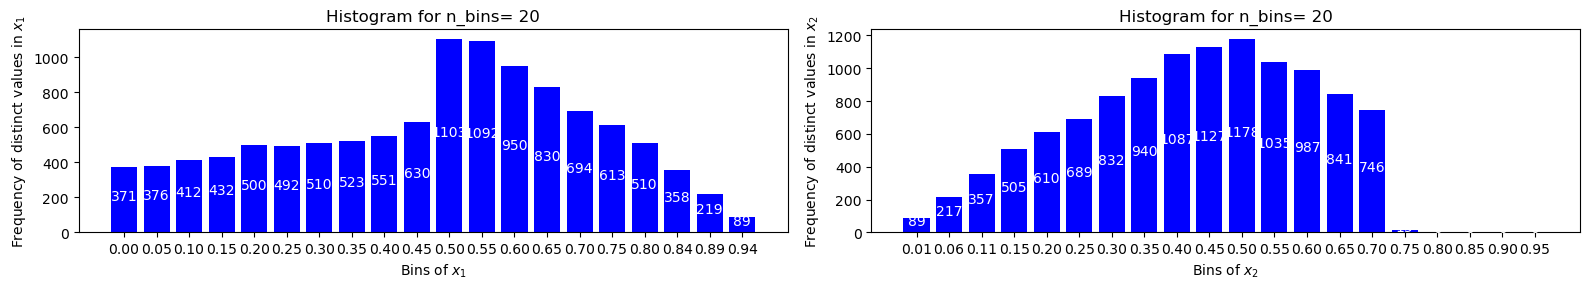

In [204]:
x_hist_sgd= []
y_hist_sgd= []
y_part_sgd= []
x_part_sgd= []
for n_bins in bins_list:
    partition_points = partition_interval(x_min, x_max, n_bins)
    x_part_sgd.append(partition_points)
#     print("Partition points:", partition_points)
    bin_counts = count_values_in_bins(x, partition_points)
    x_hist_sgd.append(bin_counts)
#     bin_counts= get_per(bin_counts)
#     print("Counts in each bin:", bin_counts)

    y_partition_points = partition_interval(y_min, y_max, n_bins)
    y_part_sgd.append(y_partition_points)
    y_bin_counts = count_values_in_bins(y, y_partition_points)
    y_hist_sgd.append(y_bin_counts)
    
#     y_bin_counts= get_per(y_bin_counts)
#     print("Counts in each bin:", y_bin_counts)


    plt.figure(figsize=(16, 3))

    plt.subplot(1, 2, 1)
    bars = plt.bar(range(len(bin_counts)), bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(bin_counts)), ["{:.2f}".format(b) for b in partition_points[:-1]])
    plt.xlabel('Bins of $x_1$')
    plt.ylabel('Frequency of distinct values in $x_1$')
    plt.title('Histogram for n_bins= {}'.format(len(bin_counts)))
#     plt.grid(True)

    plt.subplot(1, 2, 2)
    bars = plt.bar(range(len(y_bin_counts)), y_bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(y_bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(y_bin_counts)), ["{:.2f}".format(b) for b in y_partition_points[:-1]])
    plt.xlabel('Bins of $x_2$')
    plt.ylabel('Frequency of distinct values in $x_2$')
    plt.title('Histogram for n_bins= {}'.format(len(y_bin_counts)))
#     plt.grid(True)
    plt.tight_layout()
    plt.savefig('../SGD/solns_runs/Ex10/'+'ex10_sgd_hist'+str(n_bins)+'.png')
    plt.show()

## Uniform CDF vs. empirical CDF and KS-Test

## K-S Test

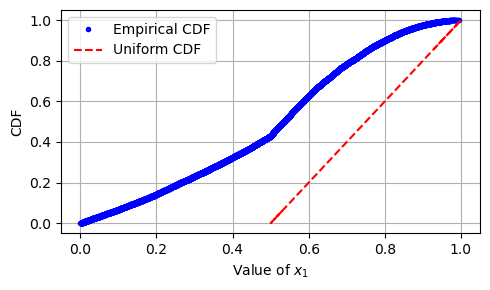

K-S Statistic: 0.10132409733388503
P-Value: 4.760513879751238e-101
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [205]:
# KS Test on x: 
a,b= 0.5,1.0
uniform_samples= np.random.uniform(low=a, high=b, size=len(xsgd))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

# Number of samples
n_samples = len(xsgd)

# Generate uniform values in [0,1]
#uniform_samples = np.random.uniform(low=0.0, high=1.0, size=n_samples)

# Plotting the histogram of uniform samples
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(xsgd)
ecdf_sgd_x = ECDF(xsgd) #np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_sgd_x.x, ecdf_sgd_x.y, marker='.', linestyle='none', label='Empirical CDF',c= 'blue')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples,cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiric')
plt.xlabel('Value of $x_1$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../SGD/solns_runs/Ex10/ks_ex10_x1.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(xsgd, "uniform")#stats.kstest(ecdf.y, stats.uniform.cdf) #stats.kstest(ecdf.y, cdf_uniform)

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.") 

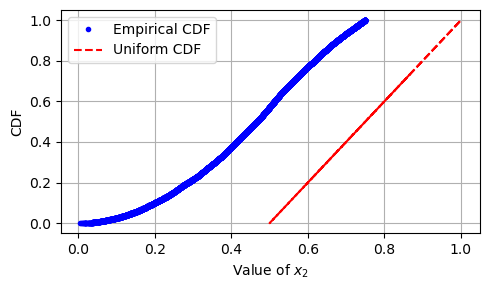

K-S Statistic: 0.2501831745897224
P-Value: 0.0
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [206]:
# KS Test on y: 
# Number of samples
a,b= 0.5, 1.0
uniform_samples = np.random.uniform(low=a, high=b, size=len(ysgd))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

n_samples = len(ysgd)
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(ysgd)
ecdf_sgd_y = ECDF(ysgd) # np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_sgd_y.x, ecdf_sgd_y.y, marker='.', linestyle='none', label='Empirical CDF', c= 'blue')
# plt.plot([1-1, 1-0.5], [1-1, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples, cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples')
plt.xlabel('Value of $x_2$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../SGD/solns_runs/Ex10/ks_ex10_x2.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(ysgd, "uniform")

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")

# KS-Overall

In [207]:
def KS_test(sample, a, b, alpha=0.05):
    ecdf_sgd_x = ECDF(sample)
    x1 = ecdf_sgd_x.x       # First coordinate
    # ecdf_sgd_y = ECDF(ysgd)
    # x2 = ecdf_sgd_y.x   # Second coordinate
    # print("Algorithm ", name)
    ks_statistic, p_value = stats.kstest(sample, "uniform", args=(a, b-a))
    print(f"K-S Statistic: {ks_statistic:.4f}")
    print(f"P-Value: {p_value:.4f}")
    if p_value > alpha:
        print(f"Result: Fail to reject H0 → Sample follows Uniform({a},{b})\n")
    else:
        print(f"Result: Reject H0 → Sample does NOT follow Uniform({a},{b})\n")

In [208]:
nubmer_points_list= [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500]

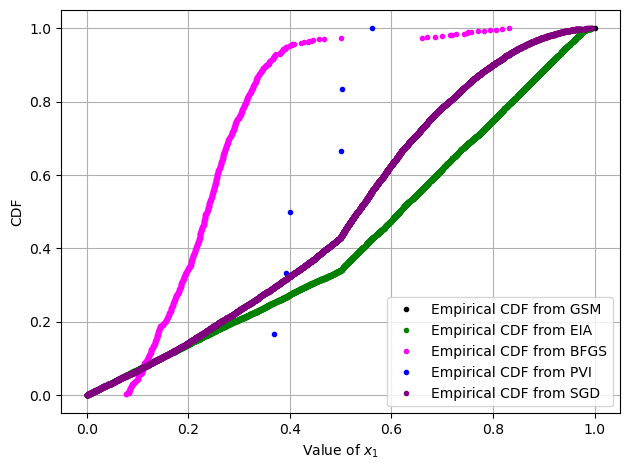

GSM
K-S Statistic: nan
P-Value: nan
Result: Reject H0 → Sample does NOT follow Uniform(1.0,1.0)

*********
EIA
K-S Statistic: 0.1632
P-Value: 0.0000
Result: Reject H0 → Sample does NOT follow Uniform(7.469714996721777e-05,0.9942592364161733)

*********
BFGS
K-S Statistic: 0.5381
P-Value: 0.0000
Result: Reject H0 → Sample does NOT follow Uniform(0.07710153839891176,0.8312415393777959)

*********
PVI
K-S Statistic: 0.3341
P-Value: 0.4206
Result: Fail to reject H0 → Sample follows Uniform(0.3688855040834411,0.5607156057051497)

*********
SGD
K-S Statistic: 0.0966
P-Value: 0.0000
Result: Reject H0 → Sample does NOT follow Uniform(0.000149447978738948,0.994006605192606)

*********


c:\Users\bbenteke\AppData\Local\anaconda3\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2066: RuntimeWarning: invalid value encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)


In [209]:
# # KS Test on x: 
# a,b= 0.5,1.0
# uniform_samples = np.random.uniform(low=a, high=b, size=len(x))
# #uniform_samples= np.hstack((uniform_samples,5))
# cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

# # Number of samples
# n_samples = len(x)

# # Generate uniform values in [0,1]
# #uniform_samples = np.random.uniform(low=0.0, high=1.0, size=n_samples)

# # Plotting the histogram of uniform samples
# plt.figure(figsize=(7, 4))

# CDF Plot
sorted_samples = np.sort(x)
ecdfgsm= ECDF(xgsm) #np.arange(1, n_samples+1) / n_samples
ecdfeia= ECDF(xeia) #np.arange(1, n_samples+1) / n_samples
ecdfbfgs= ECDF(xbfgs) #np.arange(1, n_samples+1) / n_samples
ecdfpvi= ECDF(xpvi) #np.arange(1, n_samples+1) / n_samples
ecdfsgd= ECDF(xsgd) #np.arange(1, n_samples+1) / n_samples

plt.plot(ecdfgsm.x, ecdfgsm.y, marker='.', linestyle='none', label='Empirical CDF from GSM',c= 'black')
plt.plot(ecdfeia.x, ecdfeia.y, marker='.', linestyle='none', label='Empirical CDF from EIA',c= 'green')
plt.plot(ecdfbfgs.x, ecdfbfgs.y, marker='.', linestyle='none', label='Empirical CDF from BFGS',c= 'magenta')

plt.plot(ecdfpvi.x, ecdfpvi.y, marker='.', linestyle='none', label='Empirical CDF from PVI',c= 'blue')
plt.plot(ecdfsgd.x, ecdfsgd.y, marker='.', linestyle='none', label='Empirical CDF from SGD',c= 'purple')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
# plt.plot(uniform_samples,cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiricc')
plt.xlabel('Value of $x_1$')
plt.ylabel('CDF')
# plt.xlim([0, 1])
# plt.ylim([0, 1])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../KS-Plots/Ex10/all_ks_ex10_x1.png')
plt.show()

print("GSM")
KS_test(xgsm, min(xgsm), max(xgsm), alpha=0.05)
print("*********")
print("EIA")
KS_test(xeia, min(xeia), max(xeia), alpha=0.05)
print("*********")
print("BFGS")
KS_test(xbfgs, min(xbfgs), max(xbfgs), alpha=0.05)
print("*********")
print("PVI")
KS_test(xpvi, min(xpvi), max(xpvi), alpha=0.05)
print("*********")
print("SGD")
KS_test(xsgd, min(xsgd), max(xsgd), alpha=0.05)
print("*********")

In [210]:
# uniform_samples

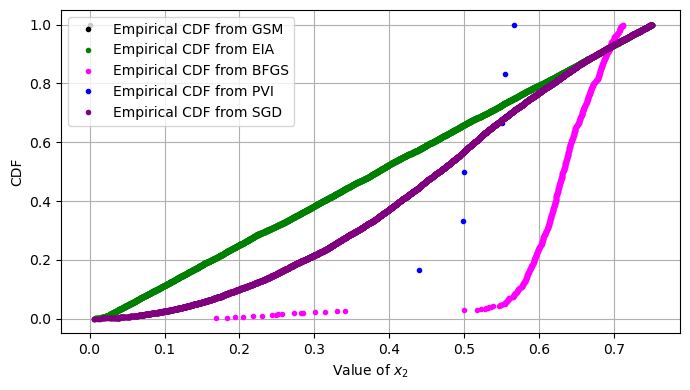

GSM
K-S Statistic: nan
P-Value: nan
Result: Reject H0 → Sample does NOT follow Uniform(0.0,0.0)

*********
EIA
K-S Statistic: 0.0156
P-Value: 0.0879
Result: Fail to reject H0 → Sample follows Uniform(0.005740763583826638,0.7499626514250164)

*********
BFGS
K-S Statistic: 0.6605
P-Value: 0.0000
Result: Reject H0 → Sample does NOT follow Uniform(0.16875846062220418,0.7114492308005441)

*********
PVI
K-S Statistic: 0.3740
P-Value: 0.2928
Result: Fail to reject H0 → Sample follows Uniform(0.4392843942948504,0.5655572479582794)

*********
SGD
K-S Statistic: 0.1810
P-Value: 0.0000
Result: Reject H0 → Sample does NOT follow Uniform(0.005993394807394014,0.7499252760106305)

*********


In [211]:
# KS Test on y: 
# Number of samples
a,b= 0.0,1.0
uniform_samples = np.random.uniform(low=a, high=b, size=len(x))
# uniform_samples= np.hstack((uniform_samples,9))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

# Number of samples
n_samples = len(x)

# Generate uniform values in [0,1]
#uniform_samples = np.random.uniform(low=0.0, high=1.0, size=n_samples)

# Plotting the histogram of uniform samples
plt.figure(figsize=(7, 4))

# CDF Plot
sorted_samples = np.sort(y)
ecdfgsm= ECDF(ygsm) #np.arange(1, n_samples+1) / n_samples
ecdfeia= ECDF(yeia) #np.arange(1, n_samples+1) / n_samples
ecdfbfgs= ECDF(ybfgs) #np.arange(1, n_samples+1) / n_samples
ecdfpvi= ECDF(ypvi) #np.arange(1, n_samples+1) / n_samples
ecdfsgd= ECDF(ysgd)

plt.plot(ecdfgsm.x, ecdfgsm.y, marker='.', linestyle='none', label='Empirical CDF from GSM',c= 'black')
plt.plot(ecdfeia.x, ecdfeia.y, marker='.', linestyle='none', label='Empirical CDF from EIA',c= 'green')
plt.plot(ecdfbfgs.x, ecdfbfgs.y, marker='.', linestyle='none', label='Empirical CDF from BFGS',c= 'magenta')

plt.plot(ecdfpvi.x, ecdfpvi.y, marker='.', linestyle='none', label='Empirical CDF from PVI',c= 'blue')
plt.plot(ecdfsgd.x, ecdfsgd.y, marker='.', linestyle='none', label='Empirical CDF from SGD',c= 'purple')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
# plt.plot(uniform_samples,cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiricc')
plt.xlabel('Value of $x_2$')
plt.ylabel('CDF')
# plt.xlim([0, 1])
# plt.ylim([0, 1])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../KS-Plots/Ex10/all_ks_ex10_x2.png')
plt.show()


    
print("GSM")
KS_test(ygsm, min(ygsm), max(ygsm), alpha=0.05)
print("*********")
print("EIA")
KS_test(yeia, min(yeia), max(yeia), alpha=0.05)
print("*********")
print("BFGS")
KS_test(ybfgs, min(ybfgs), max(ybfgs), alpha=0.05)
print("*********")
print("PVI")
KS_test(ypvi, min(ypvi), max(ypvi), alpha=0.05)
print("*********")
print("SGD")
KS_test(ysgd, min(ysgd), max(ysgd), alpha=0.05)
print("*********")

In [212]:
len(pdpgsm), len(pdpeia),len(pdpbfgs), len(pdppvi), len(pdpsgd)

(15, 15, 15, 15, 15)

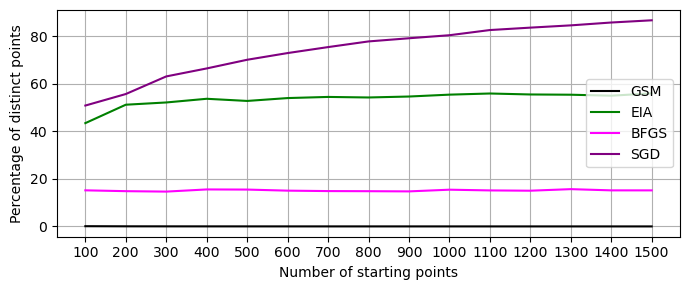

In [213]:
plt.figure(figsize=(7, 3))
plt.plot(nubmer_points_list, pdpgsm,label='GSM',c= 'black')
plt.plot(nubmer_points_list, pdpeia, label='EIA',c= 'green')
plt.plot(nubmer_points_list, pdpbfgs, label='BFGS',c= 'magenta')

#plt.plot(nubmer_points_list, pdppvi, label='PVI',c= 'blue')
plt.plot(nubmer_points_list, pdpsgd, label='SGD',c= 'purple')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiricc')
plt.xlabel('Number of starting points')
plt.ylabel('Percentage of distinct points')
plt.xticks(nubmer_points_list)
# plt.ylim([0, 1])sss
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../KS-Plots/Ex10/ex10_npoints_pdp.png')
plt.show()

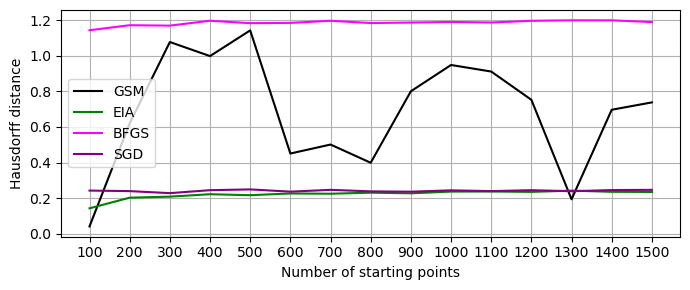

In [214]:
plt.figure(figsize=(7, 3))
plt.plot(nubmer_points_list, hdgsm,label='GSM',c= 'black')
plt.plot(nubmer_points_list, hdeia, label='EIA',c= 'green')
plt.plot(nubmer_points_list, hdbfgs, label='BFGS',c= 'magenta')

#plt.plot(nubmer_points_list, hdgpvi, label='PVI',c= 'blue')
plt.plot(nubmer_points_list, hdsgd, label='SGD',c= 'purple')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiricc')
plt.xlabel('Number of starting points')
plt.ylabel('Hausdorff distance')
plt.xticks(nubmer_points_list)
# plt.ylim([0, 1])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../KS-Plots/Ex10/ex10_npoints_hd.png')
plt.show()

In [215]:
hdsgd

[0.2425178241727777,
 0.2395058908752995,
 0.22814533222701638,
 0.2447172640293984,
 0.24909009903621038,
 0.23650352400005137,
 0.2465811615206194,
 0.23806488814275154,
 0.2362661815403471,
 0.2438734451567033,
 0.2394676172533509,
 0.24474374444469635,
 0.23887120327035458,
 0.24528672763365272,
 0.2466582883201926]

# Histograms

In [216]:
y_hist_pvi

[{0: 1, 1: 0, 2: 2, 3: 0, 4: 3},
 {0: 1, 1: 0, 2: 0, 3: 0, 4: 2, 5: 0, 6: 0, 7: 0, 8: 1, 9: 2},
 {0: 1,
  1: 0,
  2: 0,
  3: 0,
  4: 0,
  5: 0,
  6: 1,
  7: 1,
  8: 0,
  9: 0,
  10: 0,
  11: 0,
  12: 0,
  13: 2,
  14: 1},
 {0: 1,
  1: 0,
  2: 0,
  3: 0,
  4: 0,
  5: 0,
  6: 0,
  7: 0,
  8: 0,
  9: 2,
  10: 0,
  11: 0,
  12: 0,
  13: 0,
  14: 0,
  15: 0,
  16: 0,
  17: 1,
  18: 1,
  19: 1}]

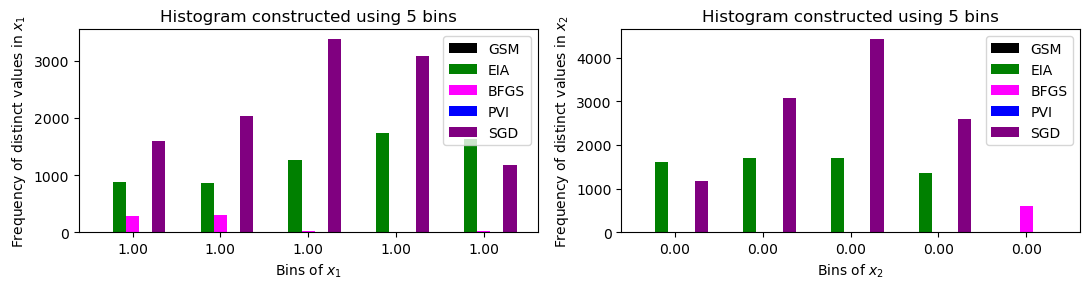

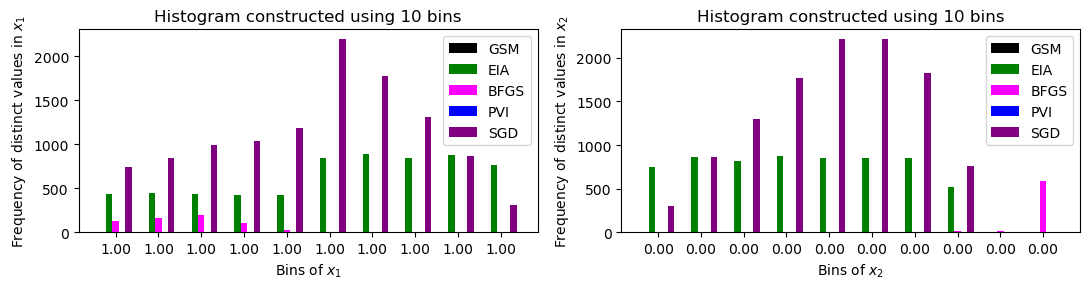

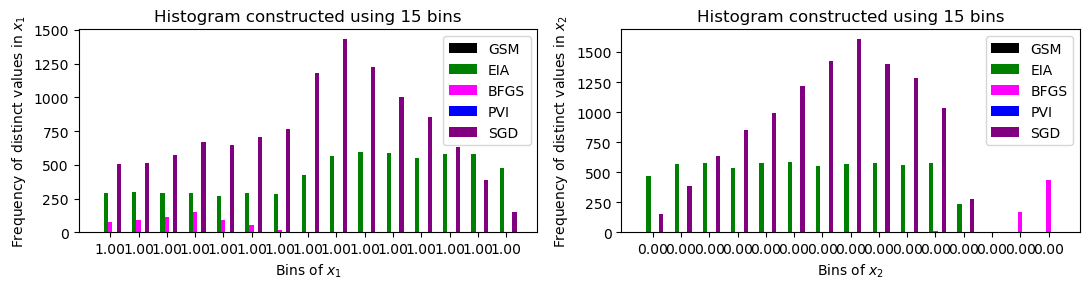

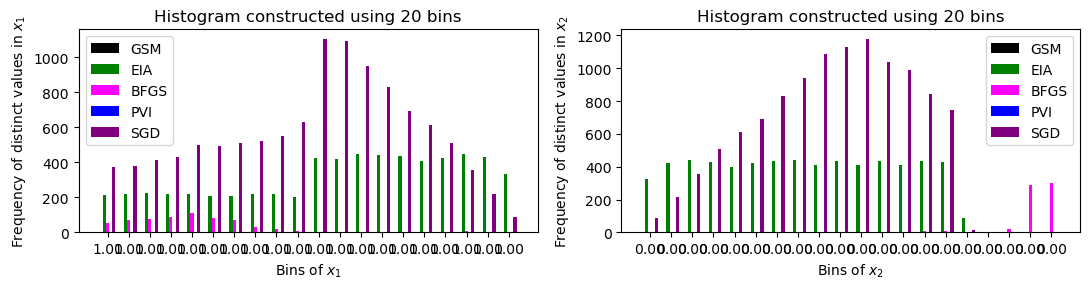

In [217]:
import matplotlib.pyplot as plt
import numpy as np

for n_bins in range(len(bins_list)):
    plt.figure(figsize=(11, 3))  # Increase the figure height for better readability
    
    width = 0.15  # Width of the bars
    
    # First subplot for x_hist_gsm and x_hist_eia
    plt.subplot(1, 2, 1)
    
    x = np.arange(len(x_hist_gsm[n_bins]))  # X locations for the groups
    
    barsgsm = plt.bar(x - 2*width, list(x_hist_gsm[n_bins].values()), width, align='center', color='black', label='GSM')
    barseia = plt.bar(x - width, list(x_hist_eia[n_bins].values()), width, align='center', color='green', label='EIA')
    barsbfgs = plt.bar(x, list(x_hist_bfgs[n_bins].values()), width, align='center', color='magenta', label='BFGS')
    barspvi = plt.bar(x + width, list(x_hist_pvi[n_bins].values()), width, align='center', color='blue', label='PVI')
    barssgd = plt.bar(x + 2*width, list(x_hist_sgd[n_bins].values()), width, align='center', color='purple', label='SGD')
    
    # Customize plot
    plt.xticks(x, ["{:.2f}".format(b) for b in x_part_gsm[n_bins][:-1]])
    plt.xlabel('Bins of $x_1$')
    plt.ylabel('Frequency of distinct values in $x_1$')
    plt.title('Histogram constructed using {} bins'.format(len(x_hist_gsm[n_bins])))
    plt.legend(loc='best', frameon=True, shadow=False)
    # plt.title('Histogram for n_bins= {}'.format(len(x_hist_gsm[n_bins])))
    # plt.legend(loc='upper right')
#     plt.grid(True)
    
    # Second subplot for y_hist_gsm and y_hist_eia
    plt.subplot(1, 2, 2)
    
    y = np.arange(len(y_hist_gsm[n_bins]))  # X locations for the groups
    
    barsgsm = plt.bar(y - 2*width, list(y_hist_gsm[n_bins].values()), width, align='center', color='black', label='GSM')
    barseia = plt.bar(y - width, list(y_hist_eia[n_bins].values()), width, align='center', color='green', label='EIA')
    barsbfgs = plt.bar(y, list(y_hist_bfgs[n_bins].values()), width, align='center', color='magenta', label='BFGS')
    barspvi = plt.bar(y + width, list(y_hist_pvi[n_bins].values()), width, align='center', color='blue', label='PVI')
    barssgd = plt.bar(y + 2*width, list(y_hist_sgd[n_bins].values()), width, align='center', color='purple', label='SGD')

    # Customize plot
    plt.xticks(y, ["{:.2f}".format(b) for b in y_part_gsm[n_bins][:-1]])
    plt.xlabel('Bins of $x_2$')
    plt.ylabel('Frequency of distinct values in $x_2$')
    plt.title('Histogram constructed using {} bins'.format(len(y_hist_gsm[n_bins])))
    plt.legend(loc='best', frameon=True, shadow=False)
    # plt.title('Histogram for n_bins= {}'.format(len(y_hist_gsm[n_bins])))
    # plt.legend(loc='upper right')
#     plt.grid(True)
    
    plt.tight_layout()
    # Uncomment the next line to save the plot
    plt.savefig('../KS-Plots/Ex10/'+'ex10_hist_bin'+str(bins_list[n_bins])+'.png')
    plt.show()


In [218]:
Ex9Sols= {
        "EIA":
                {
                    "hd": None, "pdp": None, "solutions": None
                },

     "SGD":{
        "hd":None, "pdp": None, "solutions":None
    },

     "GSM":{
        "hd":None, "pdp": None, "solutions":None
    },

     "PVI":{
        "hd":None, "pdp": None, "solutions":None
    },

     "BFGS":{
        "hd":None, "pdp": None, "solutions":None
    }



}

Algorithms= ["EIA", "SGD", "GSM", "PVI", "BFGS"]

HDResults= [hdeia, hdsgd, hdgsm, hdgpvi, hdbfgs]
PDPResults= [pdpeia, pdpsgd, pdpgsm, pdppvi, pdpbfgs]
# dataSol= [data_eia, data_sgd, data_gsm, data_pvi, data_bfgs]

for (idx, algo) in enumerate(Algorithms):

    Ex9Sols[algo]["hd"]= HDResults[idx]
    Ex9Sols[algo]["pdp"]= PDPResults[idx]
    # Ex4Sols[algo]["solutions"]= dataSol[idx]


import json

def convert_ndarray(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    raise TypeError(f"Object of type {type(obj)} is not JSON serializable")

with open("Ex9Sols.json", "w", encoding="utf-8") as f:
    json.dump(Ex9Sols, f, indent=4, default=convert_ndarray)


import json

with open("Ex9Sols.json", "r", encoding="utf-8") as f:
    Ex9Sols = json.load(f)

